In [ ]:
from process_ab_compartments import query_compartment
from methylseqnet.dataset import BaseHDF5Dataset
from methylseqnet.peaks import selected_peaks_from_target
from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import torch
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from collections import defaultdict
import pysam
from methylseqnet_repro.paths import configs, atac_atlas, methylation_atlas, preprocessed_datasets
from mpl_toolkits.axes_grid1 import make_axes_locatable
from adjustText import adjust_text

/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Lifting over coordinates using /clusterfs/nilah/oberon/genomes/hg19ToHg38.over.chain.gz ...
  Liftover: kept 2779/2779 bins (2779 rows)
       chr      start        end GM12878 H1-hESC IMR90  MES MSC  NPC  TRO  \
0     chr1    1064621    2068561     NaN       A     A  NaN   A  NaN  NaN   
1     chr1    2068562    3083436       A       A     A    A   B  NaN    A   
2     chr1    3083437    3939940       A       A     B    A   B  NaN    A   
3     chr1    3939941    4939940       A       A     B    A   B    A    A   
4     chr1    4939941    5939940       A       A     B    A   B    A    B   
...    ...        ...        ...     ...     ...   ...  ...  ..  ...  ...   
2774  chrX  150831528  151831528       A       A     B    A   B    A    B   
2775  chrX  151831529  152831456       B       A     B    A   B  NaN    B   
2776  chrX  152831457  153734546       A       A     A    A   A  NaN    A   
2777  chrX  153734547  154771725       A     NaN     A  NaN   A  NaN  NaN   
2778  chrX  15477

In [2]:
# atlas_parent_folder = Path("/global/scratch/users/dixonluinenburg/atlas_datasets/")
atlas_parent_folder = preprocessed_datasets
# methylation_parent_folder = Path("/global/scratch/users/dixonluinenburg/methylation_atlas/")
methylation_parent_folder = methylation_atlas
atlas_folder = atlas_parent_folder / "atlas"
methylation_depth_path = "41586_2022_5580_MOESM4_ESM.xlsx" #methylation_parent_folder / 
def parse_region(region_str):
    """Parse chr5:41462305-41986593 format"""
    chrom, coords = region_str.split(':')
    start, end = map(int, coords.split('-'))
    return chrom, start, end
chr_order = [f'chr{i}' for i in range(1, 23)] + ['chrX']
chr_lengths = {
    'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559,
    'chr4': 190214555, 'chr5': 181538259, 'chr6': 170805979,
    'chr7': 159345973, 'chr8': 145138636, 'chr9': 138394717,
    'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309,
    'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189,
    'chr16': 90338345, 'chr17': 83257441, 'chr18': 80373285,
    'chr19': 58617616, 'chr20': 64444167, 'chr21': 46709983,
    'chr22': 50818468, 'chrX': 156040895
}
def merge_intervals(intervals):
    """Merge overlapping intervals to get true coverage"""
    if not intervals:
        return []
    
    # Sort by start position
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]
    
    for current in intervals[1:]:
        last = merged[-1]
        if current[0] <= last[1]:  # Overlapping
            merged[-1] = (last[0], max(last[1], current[1]))
        else:
            merged.append(current)
    
    return merged
def has_stretch_enhancer(chrom, pos, tabix_file):
    """
    Check if a genomic position overlaps any stretch enhancer.
    
    Args:
        chrom: chromosome (e.g., 'chr1')
        pos: position (0-based)
        tabix_file: pysam.TabixFile object
    
    Returns:
        bool: True if position overlaps at least one stretch enhancer
    """
    try:
        # Query a 1bp region [pos, pos+1)
        overlaps = list(tabix_file.fetch(chrom, pos, pos + 1))
        return len(overlaps) > 0
    except:
        return False
def rowwise_corrcoef(X, y):
    # Center
    X_c = X - X.mean(axis=1, keepdims=True)
    y_c = y - y.mean()
    # Correlations
    num = X_c @ y_c
    denom = np.sqrt((X_c**2).sum(axis=1) * (y_c**2).sum())
    return num / denom

{'Pancreas-Acinar': 133.22, 'Adipocytes': 96.36, 'Pancreas-Alpha': 91.88999999999999, 'Lung-Alveolar-Endothel': 106.39999999999999, 'Lung-Alveolar-Epithel': 116.32, 'Lung-Alveolar-Macrophages': 67.84, 'Coronary-Artery-Smooth-Muscle': 33.1, 'Blood-B': 126.94, 'Blood-B-Mem': 42.94, 'Breast-Basal-Epithel': 95.88000000000001, 'Pancreas-Beta': 78.99000000000001, 'Lung-Bronchus-Epithel': 118.67999999999999, 'Bronchus-Smooth-Muscle': 27.94, 'Heart-Cardiomyocyte': 114.02000000000001, 'Pancreas-Delta': 70.39, 'Pancreas-Duct': 106.21, 'Aorta-Endothel': 57.03, 'Gallbladder-Epithel': 24.6, 'Bone_marrow-Erythrocyte_progenitors': 110.85, 'Heart-Fibroblasts': 112.42999999999999, 'Kidney-Glomerular-Endothel': 104.61, 'Kidney-Glomerular-Epithel': 56.64, 'Kidney-Glomerular-Podocytes': 95.49, 'Blood-Granulocytes': 96.88, 'Liver-Hepatocytes': 209.48000000000002, 'Lung-Interstitial-Macrophages': 104.86, 'Pancreas-Islet-Endothel': 29.76, 'Epidermal-Keratinocytes': 31.24, 'Colon-Left-Endocrine': 38.47, 'Colo

  0%|          | 0/1000 [00:00<?, ?it/s]

shapes: (63, 1536000) (63, 1536000) (42, 1536000) (42, 1536000)
slurm32260895task0/fold3 0.83327395 0.4201071722794452 0.7351382 0.5572951006360963 0.6767165 0.658951810292729
(42, 1536000) 0.0 1.0 (63, 1536000) 0.0 795.064
slurm32260895task0/fold3 0.72918034 0.18905145191903674 0.5267079 0.4834388513084312 0.45124936 0.46011344255638426
(42, 1536000) 0.0 1.0 (63, 1536000) 0.0 795.064


  0%|          | 0/1000 [00:00<?, ?it/s]

shapes: (63, 1536000) (63, 1536000) (42, 1536000) (42, 1536000)
slurm32260895task1/fold3 0.8077335 0.4080811588384028 0.6125071 0.4996574573402142 0.6025901 0.5704064725196416
(42, 1536000) 0.0 1.0 (63, 1536000) 0.0 795.064
slurm32260895task1/fold3 0.72573286 0.18895258862052342 0.49792823 0.4743402448648144 0.43978447 0.4337826778302181
(42, 1536000) 0.0 1.0 (63, 1536000) 0.0 795.064


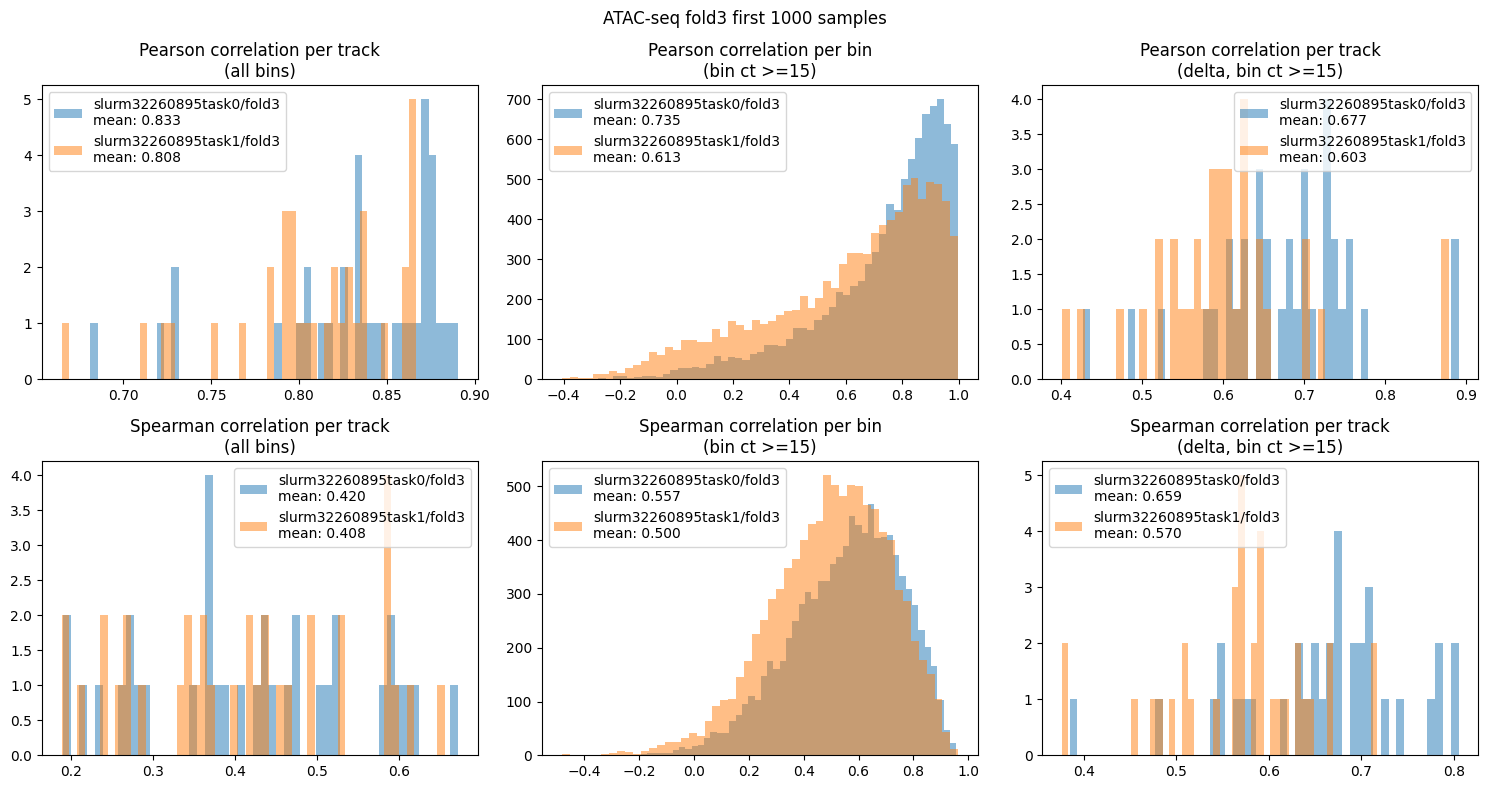

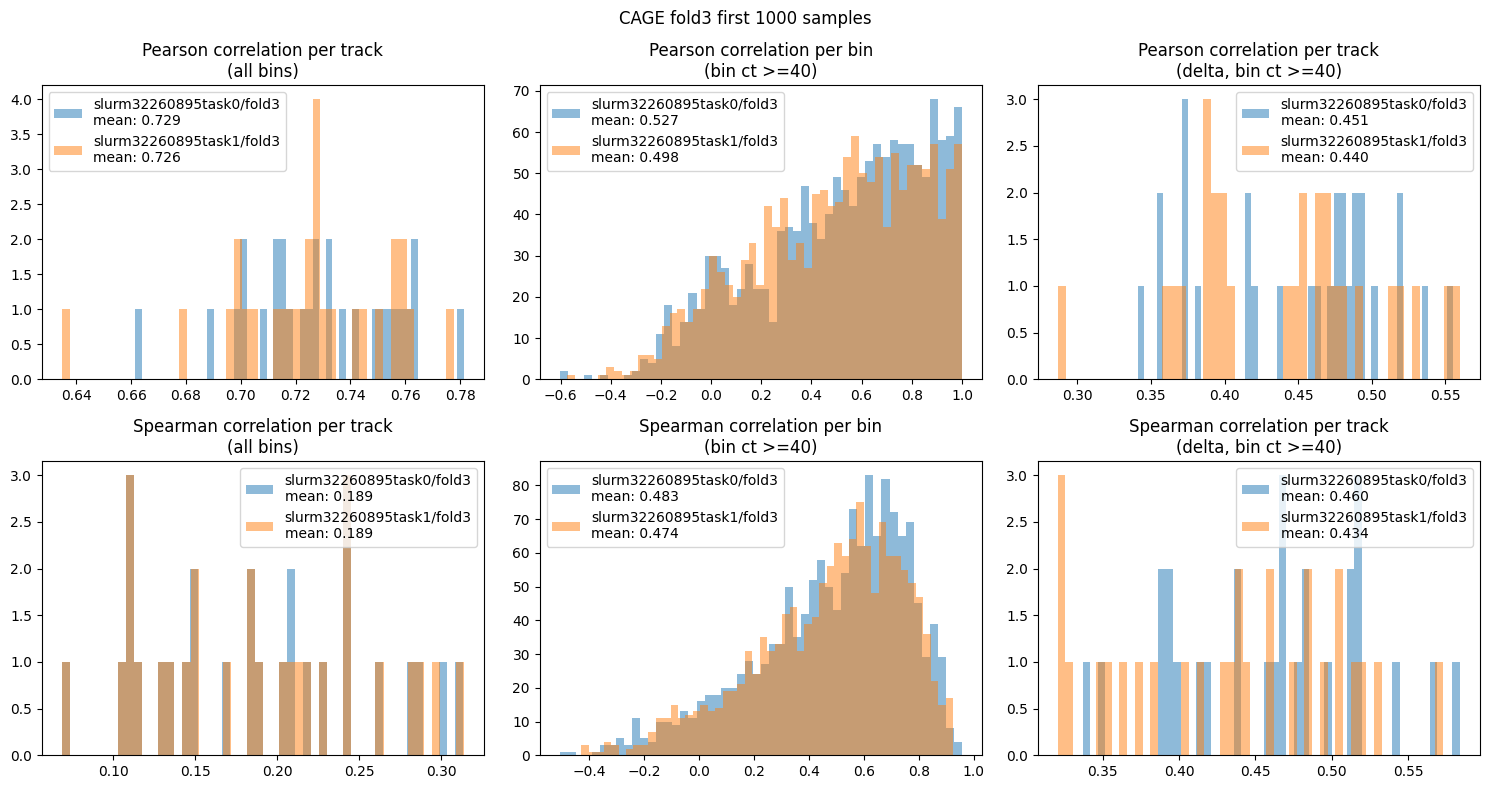


Ranked cell types by delta (Fisher z) — pearson_per_track ATAC
Rank  Cell Type                                    Delta
--------------------------------------------------------
1     Pancreas-Acinar                             0.2395
2     Pancreas-Beta                               0.2211
3     Pancreas-Alpha                              0.2079
4     Pancreas-Delta                              0.1535
5     Liver-Hepatocytes                           0.1519
6     Lung-Alveolar-Epithel                       0.1430
7     Heart-Cardiomyocyte                         0.1391
8     Pancreas-Duct                               0.1320
9     Gastric-antrum-Endocrine                    0.1289
10    Colon-Left-Epithelial                       0.1283
11    Small-int-Epithel                           0.1136
12    Breast-Luminal-Epithel                      0.1043
13    Lung-Alveolar-Macrophages                   0.0912
14    Oligodendrocytes                            0.0837
15    Breast-Basal-Epith

/tmp/ipykernel_3776701/542007530.py:386: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10')



Ranked cell types by delta (Fisher z) — pearson_per_track CAGE
Rank  Cell Type                                    Delta
--------------------------------------------------------
1     Liver-Hepatocytes                           0.0462
2     Bone-Osteoblasts                            0.0331
3     Bronchus-Smooth-Muscle                      0.0323
4     Lung-Bronchus-Epithel                       0.0291
5     Lung-Alveolar-Epithel                       0.0271
6     Saphenous-Vein-Endothel                     0.0224
7     Heart-Fibroblasts                           0.0194
8     Kidney-Tubular-Epithel                      0.0164
9     Heart-Cardiomyocyte                         0.0120
10    Breast-Luminal-Epithel                      0.0104
11    Small-int-Epithel                           0.0096
12    Kidney-Glomerular-Endothel                  0.0090
13    Aorta-Endothel                              0.0069
14    Breast-Basal-Epithel                        0.0067
15    Blood-T-CD8       

/tmp/ipykernel_3776701/542007530.py:386: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10')
/tmp/ipykernel_3776701/542007530.py:386: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10')


spearman_per_track:atac of slurm32260895task0/fold3 - slurm32260895task1/fold3
Linear regression with methylation read depth
R2=0.04924714959071641, Pearson corr=0.2219169880624653

Linear regression with match quality
R2=0.00857875106073247, Pearson corr=0.09262154749696265

Linear regression with both features
R2=0.04929356980982902, Pearson corr=0.22202155257953832



...

pearson_per_track_delta:cage of slurm32260895task0/fold3 - slurm32260895task1/fold3
Linear regression with methylation read depth
R2=0.07966734738509562, Pearson corr=0.28225404759736483

Linear regression with match quality
R2=0.043961987043375284, Pearson corr=0.20967114022529468

Linear regression with both features
R2=0.16742476770493475, Pearson corr=0.40917571739404895



/tmp/ipykernel_3776701/542007530.py:386: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10')


spearman_per_track_delta:atac of slurm32260895task0/fold3 - slurm32260895task1/fold3
Linear regression with methylation read depth
R2=0.024076166730040427, Pearson corr=0.15516496618128903

Linear regression with match quality
R2=0.028757474933509997, Pearson corr=0.16958029052195356

Linear regression with both features
R2=0.038130052412429616, Pearson corr=0.19526917937152694



/tmp/ipykernel_3776701/542007530.py:386: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10')


spearman_per_track_delta:cage of slurm32260895task0/fold3 - slurm32260895task1/fold3
Linear regression with methylation read depth
R2=0.0817510698214613, Pearson corr=0.28592143994716646

Linear regression with match quality
R2=0.18901652534541358, Pearson corr=0.43476030792312864

Linear regression with both features
R2=0.219902012537055, Pearson corr=0.46893710936228405

ATAC - problematic positions (delta > 0.5): 702
ATAC - well-predicted positions (delta < 0.1): 5732
['A', 'A', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'A', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'A', 'B', 'B', 'B', 'A', 'A', 'A', 'A', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'A', 'A', 'B', 'B', 'A', 'A', 'B', 'B'

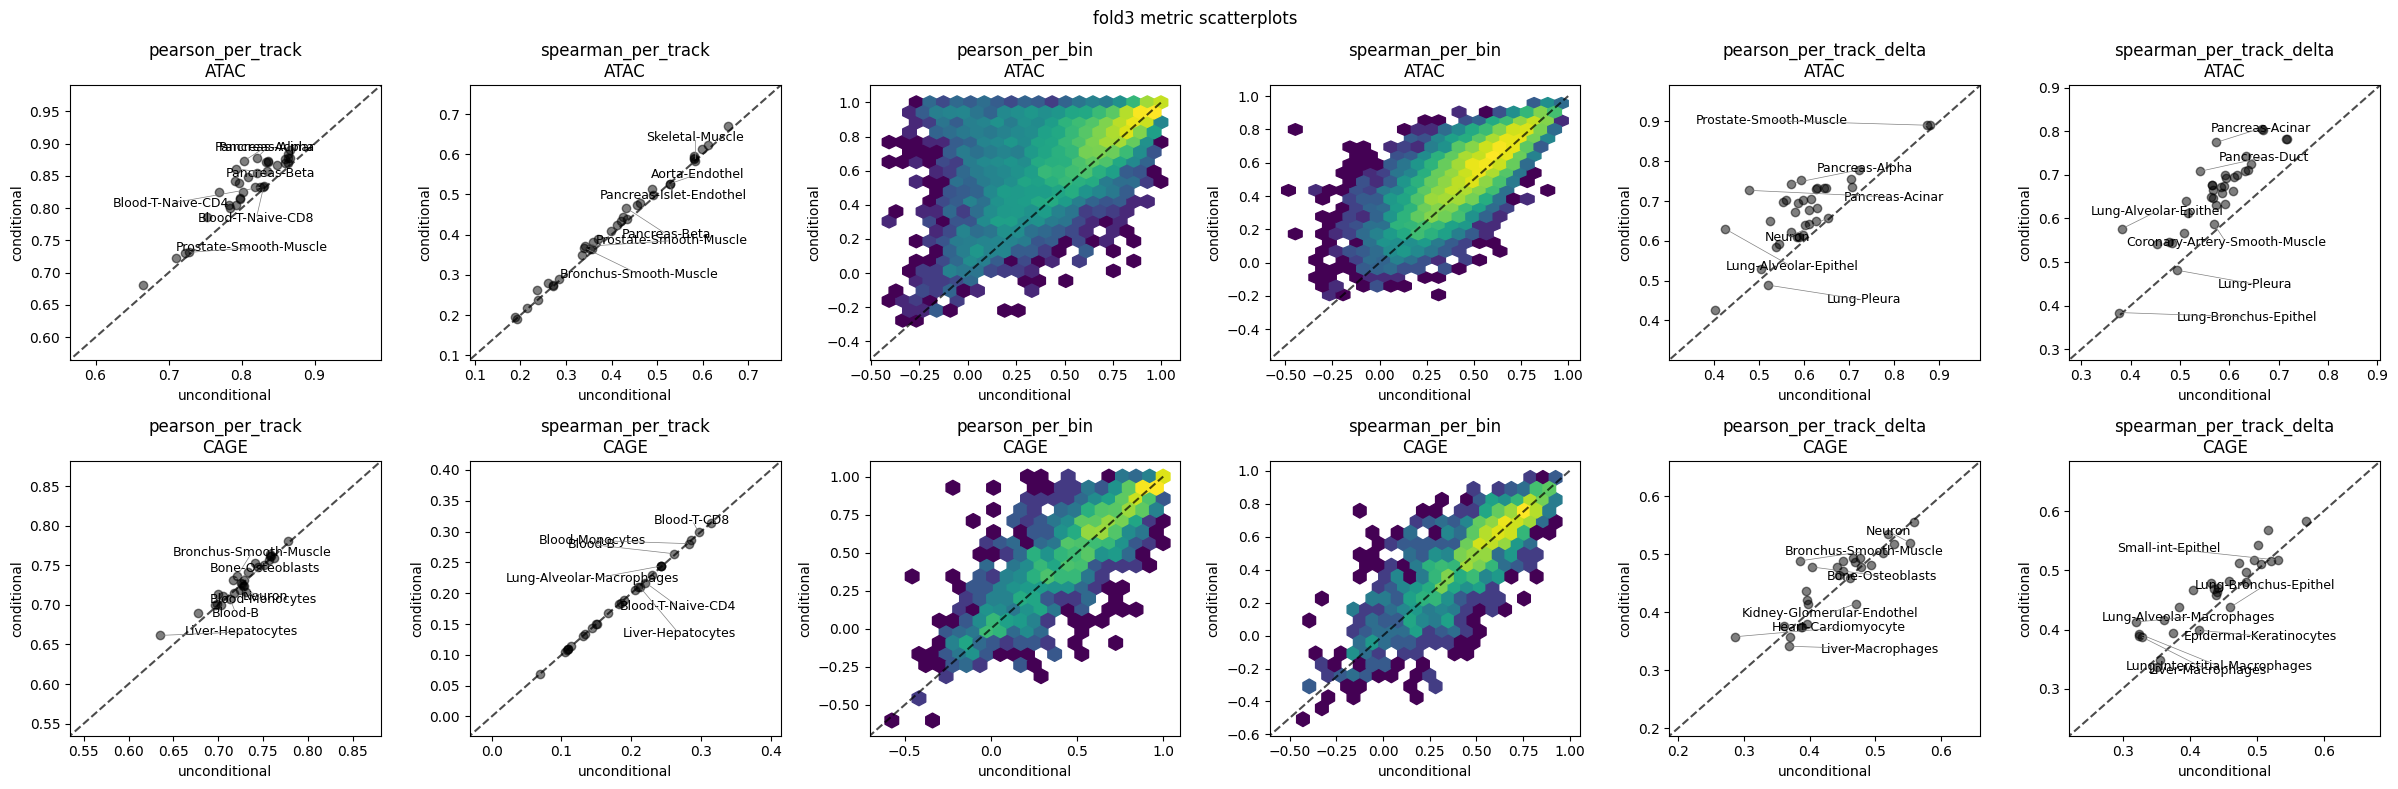

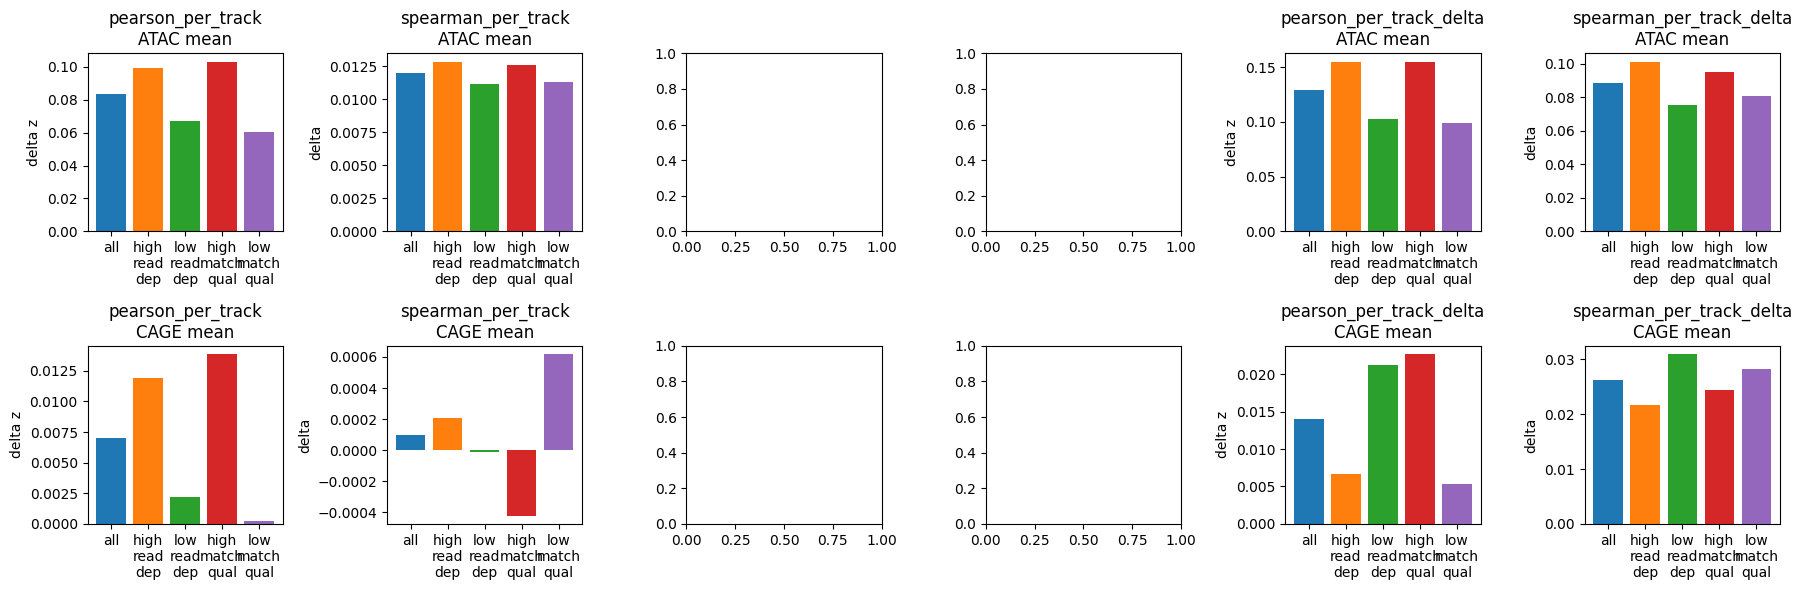

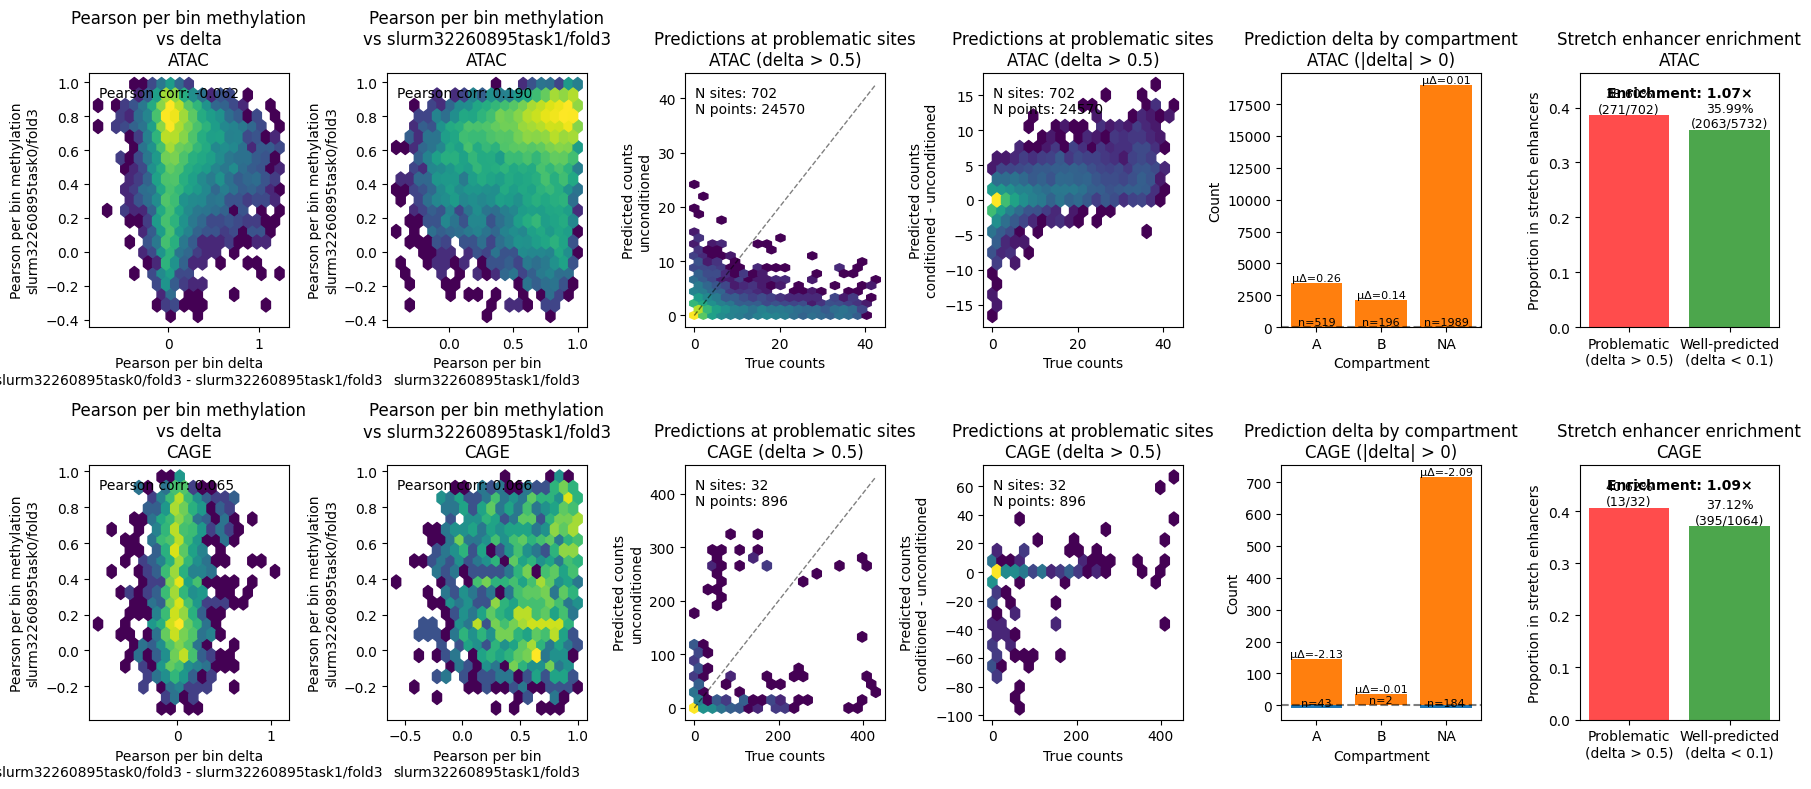

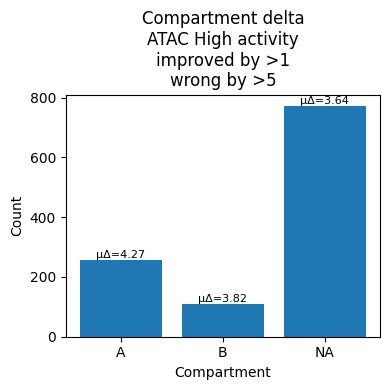

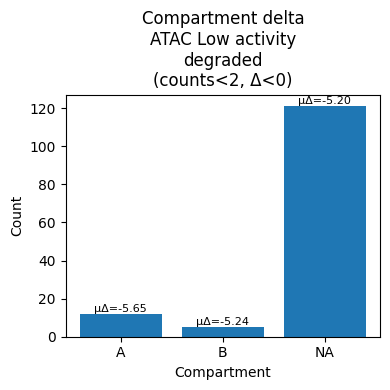

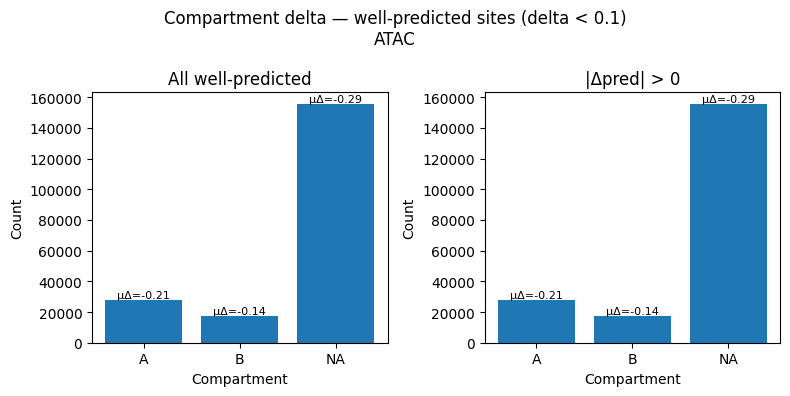

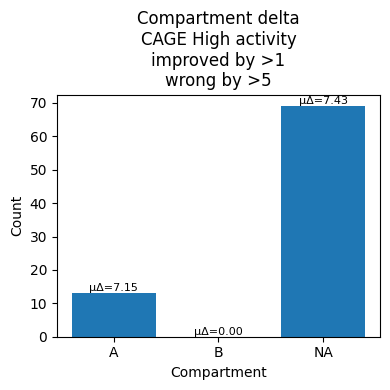

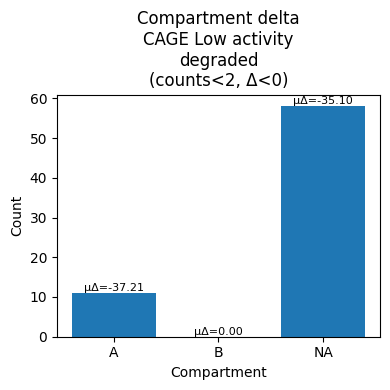

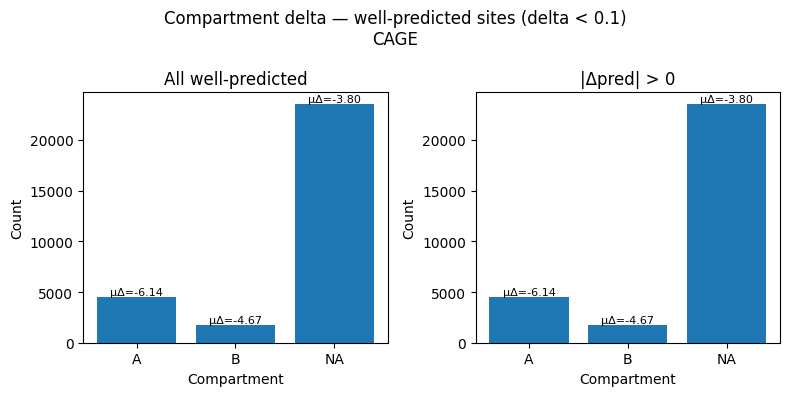

In [8]:
from matplotlib import colors

# model_identifiers = ["slurm32260895task8/fold3","slurm32260895task9/fold3"]
model_identifiers = ["slurm32260895task0/fold3","slurm32260895task1/fold3"]

# model_identifiers = ["slurm32260895task0/fold3_truecondweight_1.0","slurm32260895task0/fold3_truecondweight_0.0"] #"slurm31986468task1"]
# model_identifiers = ["slurm31983102task0/fold3_truecondweight_1.0","slurm31983102task0/fold3_truecondweight_0.0"] #"slurm31986468task1"]
# model_identifiers = ["slurm31983102task0/fold3_truecondweight_1.0","slurm31986468task1/fold3"]
# model_identifiers = ["slurm31983102task0/fold3_truecondweight_0.0","slurm31986468task1/fold3"]

datasets_to_load = {'tracks','predictions','cpg_density','true_conditioning_state_rep','imputed_conditioning_state_rep',}#'conditional_seq_rep','unconditional_seq_rep'
datasets_to_load_fallback = {'tracks','predictions','cpg_density'}

cell_type_tsv = configs / 'cell_type_matching_atac-cage.tsv'
cell_type_df = pd.read_csv(cell_type_tsv, sep='\t')
cell_type_methyl_to_atac_quality = dict(zip(cell_type_df['Methylation_Atlas'], cell_type_df['ATAC_Match_Quality']))
cell_type_methyl_to_cage_quality = dict(zip(cell_type_df['Methylation_Atlas'], cell_type_df['CAGE_Match_Quality']))
methyl_atlas_df = pd.read_excel(
    methylation_depth_path,
    sheet_name="Table S1",
    header=2,
)
cell_type_methyl_to_read_depth = dict([
    (
        methyl_cell_type,
        methyl_atlas_df[methyl_atlas_df['Sample name'].str.contains(methyl_cell_type)]['CpG coverage (fragments)'].sum())
    for methyl_cell_type in cell_type_df['Methylation_Atlas']
])
print(cell_type_methyl_to_read_depth)
min_bin_counts_crosstask = {
    'atac': 15,
    'cage': 40,
}
min_bin_counts_crossbin = {
    'atac': 0,
    'cage': 0,
}
fold = 3
bin_size = 128
stretch_enhancers = pysam.TabixFile("stretch_enhancers/stretch_enhancers_union_min2ct.bed.gz")
def collate_fn(batch):
    # Separate your data into different types
    collated_batch = {}
    for key, value in batch[0].items():
        if isinstance(value, str):
            collated_batch[key] = [item[key] for item in batch]
        elif isinstance(value, torch.Tensor):
            collated_batch[key] = torch.stack([item[key] for item in batch])
        elif isinstance(value, np.ndarray):
            collated_batch[key] = np.stack([item[key] for item in batch])
        else:
            raise TypeError(f"Unsupported data type for key {key}: {type(value)}")
    return collated_batch
max_samples = 1000
atac_fig, atac_axs = plt.subplots(2,3, figsize=(15,8))
cage_fig, cage_axs = plt.subplots(2,3, figsize=(15,8))
samples = f"first {max_samples} samples" if max_samples is not None else "all samples"
atac_fig.suptitle(f'ATAC-seq fold{fold} {samples}')
cage_fig.suptitle(f'CAGE fold{fold} {samples}')
metrics_dict = {}
celltype_names = {}
match_qualities = {}
methyl_read_depth = {}
for model_idx, model_identifier in enumerate(model_identifiers):
    chr_regions = defaultdict(list)
    metrics_dict[model_identifier] = {}
    celltype_names[model_identifier] = {}
    match_qualities[model_identifier] = {}
    methyl_read_depth[model_identifier] = {}
    dataset_path = atlas_folder / model_identifier / "predictions.h5"
    try:
        dataset = BaseHDF5Dataset(dataset_path,datasets=datasets_to_load,return_specifiers=True)
    except Exception as e:
        print(e)
        dataset = BaseHDF5Dataset(dataset_path,datasets=datasets_to_load_fallback,return_specifiers=True)
    io_mappings_df = dataset.get_io_mappings_df()
    atac_channels = io_mappings_df[io_mappings_df['data_type']=='ATAC-seq']['channel'].tolist()
    atac_df = io_mappings_df[io_mappings_df['data_type']=='ATAC-seq'].copy()
    celltype_names[model_identifier]['atac'] = atac_df['methylation_files'].str.strip("[]'").tolist()
    match_qualities[model_identifier]['atac'] = atac_df['methylation_files'].str.strip("[]'").map(cell_type_methyl_to_atac_quality).tolist()
    methyl_read_depth[model_identifier]['atac'] = atac_df['methylation_files'].str.strip("[]'").map(cell_type_methyl_to_read_depth).tolist()
    cage_channels = io_mappings_df[io_mappings_df['data_type']=='CAGE-seq']['channel'].tolist()
    cage_df = io_mappings_df[io_mappings_df['data_type']=='CAGE-seq'].copy()
    celltype_names[model_identifier]['cage'] = cage_df['methylation_files'].str.strip("[]'").tolist()
    match_qualities[model_identifier]['cage'] = cage_df['methylation_files'].str.strip("[]'").map(cell_type_methyl_to_cage_quality).tolist()
    methyl_read_depth[model_identifier]['cage'] = cage_df['methylation_files'].str.strip("[]'").map(cell_type_methyl_to_read_depth).tolist()
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)
    targets_list = []
    predictions_list = []
    methylations_list = []
    imputed_methylations_list = []
    cpg_density_list = []
    conditional_seq_rep_list = []
    unconditional_seq_rep_list = []
    regions_list = []
    for idx, sample in tqdm(enumerate(dataloader),total=max_samples if max_samples is not None else len(dataloader)):
        if max_samples is not None and idx >= max_samples:
            break
        targets_list.append(sample['tracks'].squeeze().numpy())
        predictions_list.append(sample['predictions'].squeeze().numpy())
        methylations_list.append(sample.get('true_conditioning_state_rep', sample['tracks']).squeeze().numpy())
        imputed_methylations_list.append(sample.get('imputed_conditioning_state_rep', sample['predictions']).squeeze().numpy())
        cpg_density_list.append(sample['cpg_density'].squeeze().numpy())
        conditional_seq_rep_list.append(sample.get('conditional_seq_rep', torch.zeros_like(sample['predictions'])).squeeze().numpy())
        unconditional_seq_rep_list.append(sample.get('unconditional_seq_rep', torch.zeros_like(sample['predictions'])).squeeze().numpy())
        region_str = sample['specifier'][0][0].split('|')[0]
        regions_list.append(region_str)
        if region_str:
            try:
                chrom, start, end = parse_region(region_str)
                chr_regions[chrom].append((start, end))
            except:
                pass
    chr_merged = {}
    for chrom, regions in chr_regions.items():
        chr_merged[chrom] = merge_intervals(regions)


    all_targets = np.concatenate(targets_list,axis=1)
    all_predictions = np.concatenate(predictions_list,axis=1)
    all_methylations = np.concatenate(methylations_list, axis=1)
    all_imputed_methylations = np.concatenate(imputed_methylations_list, axis=1)
    all_cpg_densities = np.concatenate(cpg_density_list, axis=0)
    all_conditional_seq_reps = np.concatenate(conditional_seq_rep_list, axis=1)
    all_unconditional_seq_reps = np.concatenate(unconditional_seq_rep_list, axis=1)

    print("shapes:", all_targets.shape, all_predictions.shape, all_methylations.shape, all_imputed_methylations.shape)
    for axs, channels, label in [(atac_axs, atac_channels, 'atac'), (cage_axs, cage_channels, 'cage')]:
        targets = all_targets[channels,:]
        predictions = all_predictions[channels,:]
        # print(targets.shape, predictions.shape)
        mean_targets_by_bin = np.mean(targets, axis=0)
        mean_predictions_by_bin = np.mean(predictions, axis=0)
        # low_counts_mask = targets.max(axis=0) < min_bin_counts_crosstask[label]
        # high_counts_indices = np.where(~low_counts_mask)[0]
        high_counts_indices = selected_peaks_from_target(
            target = targets.max(axis=0),
            peak_threshold = min_bin_counts_crosstask[label],
            min_peak_distance_bins = 8,
            )
        # print(high_counts_indices.shape)
        delta_from_mean_targets = targets - mean_targets_by_bin[np.newaxis, :]
        delta_from_mean_predictions = predictions - mean_predictions_by_bin[np.newaxis, :]
        delta_from_mean_methylations = all_methylations - mean_targets_by_bin[np.newaxis, :]
        delta_from_mean_imputed_methylations = all_imputed_methylations - mean_predictions_by_bin[np.newaxis, :]
        
        pearson_corrs = []
        spearman_corrs = []
        pearson_corrs_taskwise = []
        spearman_corrs_taskwise = []
        pearson_corrs_delta = []
        spearman_corrs_delta = []
        target_values_high_counts = targets[:,high_counts_indices]
        prediction_values_high_counts = predictions[:,high_counts_indices]

        pearson_corrs_methylation = []
        spearman_corrs_methylation = []
        pearson_corrs_methylation_taskwise = []
        spearman_corrs_methylation_taskwise = []
        pearson_corrs_methylation_delta = []
        spearman_corrs_methylation_delta = [] 

        high_count_loci = []
        stretch_enhancer_found = []
        
        bins_per_region = targets.shape[1] // len(regions_list)

        for bin_index in high_counts_indices:
            region_index = bin_index // bins_per_region
            bins_subindex = bin_index % bins_per_region
            try:
                region_chrom = regions_list[region_index].split(':')[0]
                region_start = int(regions_list[region_index].split(':')[1].split('-')[0])
                region_end = int(regions_list[region_index].split(':')[1].split('-')[1])
                region_with_labels = bins_per_region * bin_size
                high_count_locus = (region_chrom,int((region_start + region_end)//2 - region_with_labels//2 + (bins_subindex+0.5)*bin_size))
                high_count_loci.append(high_count_locus)
                stretch_enhancer_found.append(has_stretch_enhancer(*high_count_locus, stretch_enhancers))
            except:
                high_count_loci.append(('none',-1))
                stretch_enhancer_found.append(False)
            pearson_corrs_taskwise.append(pearsonr(targets[:,bin_index], predictions[:,bin_index])[0])
            spearman_corrs_taskwise.append(spearmanr(targets[:,bin_index], predictions[:,bin_index])[0])
            pearson_corrs_methylation_taskwise.append(pearsonr(all_methylations[:,bin_index], all_imputed_methylations[:,bin_index])[0])
            spearman_corrs_methylation_taskwise.append(spearmanr(all_methylations[:,bin_index], all_imputed_methylations[:,bin_index])[0])
        for track_idx in range(targets.shape[0]):
            pearson_corrs.append(pearsonr(targets[track_idx], predictions[track_idx])[0])
            spearman_corrs.append(spearmanr(targets[track_idx], predictions[track_idx])[0])
            # print(logfold_delta_from_mean_targets[track_idx,high_counts_indices], logfold_delta_from_mean_predictions[track_idx,high_counts_indices])
            pearson_corrs_delta.append(pearsonr(delta_from_mean_targets[track_idx,high_counts_indices], delta_from_mean_predictions[track_idx,high_counts_indices])[0])
            spearman_corrs_delta.append(spearmanr(delta_from_mean_targets[track_idx,high_counts_indices], delta_from_mean_predictions[track_idx,high_counts_indices])[0])
        for cell_type_idx in range(all_methylations.shape[0]):
            pearson_corrs_methylation.append(pearsonr(all_methylations[cell_type_idx], all_imputed_methylations[cell_type_idx]))
            spearman_corrs_methylation.append(spearmanr(all_methylations[cell_type_idx], all_imputed_methylations[cell_type_idx])[0])
            pearson_corrs_methylation_delta.append(pearsonr(
                delta_from_mean_methylations[cell_type_idx,high_counts_indices],
                delta_from_mean_imputed_methylations[cell_type_idx,high_counts_indices],
            )[0])
            spearman_corrs_methylation_delta.append(spearmanr(
                delta_from_mean_methylations[cell_type_idx,high_counts_indices],
                delta_from_mean_imputed_methylations[cell_type_idx,high_counts_indices],
            )[0])
        
        metrics_dict[model_identifier][label] = {}
        metrics_dict[model_identifier][label]['pearson_per_track'] = pearson_corrs
        metrics_dict[model_identifier][label]['spearman_per_track'] = spearman_corrs
        metrics_dict[model_identifier][label]['pearson_per_bin'] = pearson_corrs_taskwise
        metrics_dict[model_identifier][label]['spearman_per_bin'] = spearman_corrs_taskwise
        metrics_dict[model_identifier][label]['pearson_per_track_delta'] = pearson_corrs_delta
        metrics_dict[model_identifier][label]['spearman_per_track_delta'] = spearman_corrs_delta
        metrics_dict[model_identifier][label]['target_values_high_counts'] = target_values_high_counts
        metrics_dict[model_identifier][label]['prediction_values_high_counts'] = prediction_values_high_counts
        metrics_dict[model_identifier][label]['pearson_per_track_methylation'] = pearson_corrs_methylation
        metrics_dict[model_identifier][label]['spearman_per_track_methylation'] = spearman_corrs_methylation
        metrics_dict[model_identifier][label]['pearson_per_track_delta_methylation'] = pearson_corrs_methylation_delta
        metrics_dict[model_identifier][label]['spearman_per_track_delta_methylation'] = spearman_corrs_methylation_delta
        metrics_dict[model_identifier][label]['pearson_per_bin_methylation'] = pearson_corrs_methylation_taskwise
        metrics_dict[model_identifier][label]['spearman_per_bin_methylation'] = spearman_corrs_methylation_taskwise
        metrics_dict[model_identifier][label]['high_count_loci'] = high_count_loci
        metrics_dict[model_identifier][label]['stretch_enhancer_found'] = stretch_enhancer_found
        
        print(model_identifier,np.mean(pearson_corrs), np.mean(spearman_corrs), np.mean(pearson_corrs_taskwise), np.mean(spearman_corrs_taskwise), np.mean(pearson_corrs_delta), np.mean(spearman_corrs_delta))
        axs[0,0].hist(pearson_corrs, bins=50, alpha=0.5, label=f'{model_identifier}\nmean: {np.nanmean(pearson_corrs):.3f}')
        axs[1,0].hist(spearman_corrs, bins=50, alpha=0.5, label=f'{model_identifier}\nmean: {np.nanmean(spearman_corrs):.3f}')
        axs[0,0].set_title('Pearson correlation per track\n(all bins)')
        axs[1,0].set_title('Spearman correlation per track\n(all bins)')
        axs[0,0].legend()
        axs[1,0].legend()
        axs[0,1].hist(pearson_corrs_taskwise, bins=50, alpha=0.5, label=f'{model_identifier}\nmean: {np.nanmean(pearson_corrs_taskwise):.3f}')
        axs[1,1].hist(spearman_corrs_taskwise, bins=50, alpha=0.5, label=f'{model_identifier}\nmean: {np.nanmean(spearman_corrs_taskwise):.3f}')
        axs[0,1].set_title(f'Pearson correlation per bin\n(bin ct >={min_bin_counts_crosstask[label]})')
        axs[1,1].set_title(f'Spearman correlation per bin\n(bin ct >={min_bin_counts_crosstask[label]})')
        axs[0,1].legend()
        axs[1,1].legend()
        axs[0,2].hist(pearson_corrs_delta, bins=50, alpha=0.5, label=f'{model_identifier}\nmean: {np.nanmean(pearson_corrs_delta):.3f}')
        axs[1,2].hist(spearman_corrs_delta, bins=50, alpha=0.5, label=f'{model_identifier}\nmean: {np.nanmean(spearman_corrs_delta):.3f}')
        axs[0,2].set_title(f'Pearson correlation per track\n(delta, bin ct >={min_bin_counts_crosstask[label]})')
        axs[1,2].set_title(f'Spearman correlation per track\n(delta, bin ct >={min_bin_counts_crosstask[label]})')
        axs[0,2].legend()
        axs[1,2].legend()
        active_sites = np.where(all_targets[atac_channels,:].max(axis=0) > min_bin_counts_crosstask['atac'])[0]

        active_site_target_cov = all_targets[atac_channels][:,active_sites].var(axis=0) / (all_targets[atac_channels][:,active_sites].mean(axis=0)+1e-5)
        active_site_methylation_cov = all_methylations[:,active_sites].var(axis=0) / (all_methylations[:,active_sites].mean(axis=0)+1e-5)
        print(all_methylations.shape,all_methylations.min(),all_methylations.max(),all_targets.shape,all_targets.min(),all_targets.max())
        # fig, ax = plt.subplots(figsize=(6,4))
        # ax.scatter(active_site_target_cov, active_site_methylation_cov, alpha=0.5)
        # ax.loglog()
        # fig.show()
    # reps_fig, reps_axs = plt.subplots(2,2, figsize=(8,8))
    # reps_fig.suptitle(f"Embedding feature analysis at active sites\n{model_identifier}")
    # conditional_correlations = rowwise_corrcoef(all_conditional_seq_reps[:,active_sites], all_cpg_densities[active_sites])
    # unconditional_correlations = rowwise_corrcoef(all_unconditional_seq_reps[:,active_sites], all_cpg_densities[active_sites])
    # conditional_means = all_conditional_seq_reps[:,active_sites].mean(axis=1)
    # unconditional_means = all_unconditional_seq_reps[:,active_sites].mean(axis=1)
    # conditional_variances = all_conditional_seq_reps[:,active_sites].var(axis=1)
    # unconditional_variances = all_unconditional_seq_reps[:,active_sites].var(axis=1)
    # conditional_fve = (np.abs(conditional_correlations) * conditional_variances).sum() / conditional_variances.sum()
    # unconditional_fve = (np.abs(unconditional_correlations) * unconditional_variances).sum() / unconditional_variances.sum()
    # reps_axs[0,0].hist(np.abs(conditional_correlations), bins=50, alpha=0.5, label=f'conditional rep\nmean: {np.nanmean(np.abs(conditional_correlations)):.3f}')
    # reps_axs[0,0].hist(np.abs(unconditional_correlations), bins=50, alpha=0.5, label=f'unconditional rep\nmean: {np.nanmean(np.abs(unconditional_correlations)):.3f}')
    # reps_axs[0,0].legend()
    # reps_axs[0,0].set_title("Embeddings activations across active sites\ncorrelation with CpG density")
    # reps_axs[0,0].set_xlabel('abs(correlation with CpG density)')
    # reps_axs[0,0].set_ylabel('count')
    # # reps_axs[0,1].scatter(active_site_methylation_cov,active_site_target_cov, alpha=0.5)
    # reps_axs[1,0].scatter(conditional_correlations,conditional_variances, color='purple', alpha=0.5, label=f'conditional') #rep\nmean: {np.nanmean(conditional_variances):.3f}
    # reps_axs[1,0].scatter(unconditional_correlations,unconditional_variances, color='green', alpha=0.5, label=f'unconditional') # rep\nmean: {np.nanmean(unconditional_variances):.3f}'
    # reps_axs[1,0].legend()
    # reps_axs[1,0].legend()
    # reps_axs[1,0].set_xlabel('correlation with CpG density\nacross test set active sites')
    # reps_axs[1,0].set_ylabel('feature variance\nacross test set active sites')
    # ax = reps_axs[1,0]  # your scatter panel
    # divider = make_axes_locatable(ax)
    # ax_histx = divider.append_axes("top", 0.6, pad=0.1, sharex=ax)
    # ax_histy = divider.append_axes("right", 0.6, pad=0.1, sharey=ax)
    # ax_histx.tick_params(labelbottom=False)
    # ax_histy.tick_params(labelleft=False)
    # ax_histx.set_yscale('log')
    # ax_histy.set_xscale('log')
    # ax_histx.set_title("Feature variance vs correlation\nwith CpG density")

    # ax_histx.hist(conditional_correlations, bins=np.arange(-0.5,1,0.03), alpha=0.5, color='purple')
    # ax_histx.hist(unconditional_correlations, bins=np.arange(-0.5,1,0.03), alpha=0.5, color='green')
    # ax_histy.hist(conditional_variances, bins=np.arange(0,100,2), alpha=0.5, color='purple', orientation='horizontal')
    # ax_histy.hist(unconditional_variances, bins=np.arange(0,100,2), alpha=0.5, color='green', orientation='horizontal')
    # # reps_axs[1,0].scatter(active_site_methylation_cov, all_conditional_seq_reps[:, active_sites].mean(axis=0), alpha=0.5, label=f'conditional rep\nmean: {np.nanmean(all_conditional_seq_reps):.3f}')
    # # reps_axs[1,0].scatter(active_site_methylation_cov, all_unconditional_seq_reps[:, active_sites].mean(axis=0), alpha=0.5, label=f'unconditional rep\nmean: {np.nanmean(all_unconditional_seq_reps):.3f}')
    # # reps_axs[1,0].legend()
    # # Conditional
    # cond_order = np.argsort(conditional_variances)[::-1]
    # cond_cumvar_frac = np.cumsum(conditional_variances[cond_order]) / conditional_variances.sum() * 100
    # cond_cum_explained = np.cumsum((conditional_correlations[cond_order]**2 * conditional_variances[cond_order])) / conditional_variances.sum() * 100

    # # Unconditional
    # uncond_order = np.argsort(unconditional_variances)[::-1]
    # uncond_cumvar_frac = np.cumsum(unconditional_variances[uncond_order]) / unconditional_variances.sum() * 100
    # uncond_cum_explained = np.cumsum((unconditional_correlations[uncond_order]**2 * unconditional_variances[uncond_order])) / unconditional_variances.sum() * 100

    # ax = reps_axs[1,1]
    # ax.plot(cond_cumvar_frac, cond_cum_explained, color='purple', label='conditional')
    # ax.plot(uncond_cumvar_frac, uncond_cum_explained, color='green', label='unconditional')
    # ax.set_xlabel('% total embedding variance explained\nby top N features (ranked by variance)')
    # ax.set_ylabel('% total variance explained\nby CpG density')
    # ax.set_title('Cumulative ranked feature variance\nexplained by CpG density')
    # ax.legend()
    # reps_fig.tight_layout()
atac_fig.tight_layout()
cage_fig.tight_layout()
plt.show()
scatterplot_metrics = ['pearson_per_track', 'spearman_per_track', 'pearson_per_bin', 'spearman_per_bin', 'pearson_per_track_delta', 'spearman_per_track_delta']
fig, axs = plt.subplots(2,len(scatterplot_metrics), figsize=(24,8))
fig_bars, axs_bars = plt.subplots(2,len(scatterplot_metrics), figsize=(18,6))
fig.suptitle(f"fold{fold} metric scatterplots")
for metric_idx, metric in enumerate(scatterplot_metrics):
    for data_type_idx, data_type in enumerate(['atac', 'cage']):
        x = metrics_dict[model_identifiers[1]][data_type][metric]
        y = metrics_dict[model_identifiers[0]][data_type][metric]
        if len(x) > 1000:
            alpha = 0.1
        else:
            alpha = 0.5
        if 'per_bin' not in metric:
            # if data_type == 'atac':
            #     arr = np.array(x)
            #     indices = np.argpartition(arr, 3)[:3]  # Get indices of 3 smallest
            #     indices = indices[np.argsort(arr[indices])]  # Sort them by value
            #     values = arr[indices]

            #     print(f"Indices: {indices}")  # [3, 1, 5]
            #     channels = np.array(atac_channels)[indices]
            #     for channel in channels:
            #         print(io_mappings_df[io_mappings_df['channel']==channel])
            #     print(f"Values: {values}")  
            # colors = match_qualities[model_identifiers[0]][data_type]
            colors_array = np.array(match_qualities[model_identifiers[0]][data_type])
            scatter_colors = colors_array > np.median(colors_array)
            # print(colors)
            scatter = axs[data_type_idx,metric_idx].scatter(
                x = x,
                y = y,
                alpha=alpha,
                c='black',
                # cmap='viridis',
                # norm=matplotlib.colors.LogNorm(),
            )
            topk = 3
            most_improved = set(np.argsort(np.array(x)-np.array(y))[-topk:])
            least_improved = set(np.argsort(np.array(x)-np.array(y))[:topk])
            label_idxs = most_improved | least_improved
            texts = []
            for i in label_idxs:
                texts.append(axs[data_type_idx,metric_idx].annotate(
                    celltype_names[model_identifier][data_type][i],
                    (x[i], y[i]),
                    fontsize=9,
                ))

            adjust_text(
                texts,
                ax=axs[data_type_idx, metric_idx],
                expand=(3.0, 3.0),
                force_text=(1.5, 1.5),
                force_points=(1.0, 1.0),
                force_static=(1.0, 1.0),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                iter_lim=1000,
            )
            # Print ranked table of cell type deltas
            if metric_idx == 0:  # Only print once per data_type (e.g., for first metric)
                delta_z = np.arctanh(np.array(y)) - np.arctanh(np.array(x)) if 'pearson' in metric else np.array(y) - np.array(x)
                ct_names = celltype_names[model_identifier][data_type]
                ranked_indices = np.argsort(delta_z)[::-1]  # best improvement first
                print(f"\n{'='*60}")
                print(f"Ranked cell types by delta ({'Fisher z' if 'pearson' in metric else 'raw'}) — {metric} {data_type.upper()}")
                print(f"{'Rank':<6}{'Cell Type':<40}{'Delta':>10}")
                print(f"{'-'*56}")
                for rank, i in enumerate(ranked_indices, 1):
                    print(f"{rank:<6}{ct_names[i]:<40}{delta_z[i]:>10.4f}")
                print(f"{'='*60}\n")
            # fig.colorbar(scatter, ax=axs[data_type_idx,metric_idx], label='Match Quality')
            axs[data_type_idx,metric_idx].plot([-1,1],[-1,1], color='black', linestyle='--',alpha=0.7)
            delta_metric = np.arctanh(np.array(y))-np.arctanh(np.array(x)) if 'pearson' in metric else np.array(y)-np.array(x)
            methyl_read_depth_values = np.array(methyl_read_depth[model_identifiers[0]][data_type])
            match_quality_values = np.array(match_qualities[model_identifiers[0]][data_type])
            cmap = plt.cm.get_cmap('tab10')
            bar_colors = [cmap(i) for i in range(5)]
            array_for_bars = np.array(delta_metric)
            axs_bars[data_type_idx,metric_idx].bar(
                ['all', 'high\nread\ndep', 'low\nread\ndep', 'high\nmatch\nqual', 'low\nmatch\nqual'],
                [
                    array_for_bars.mean(),
                    array_for_bars[methyl_read_depth_values >= np.median(methyl_read_depth_values)].mean(),
                    array_for_bars[methyl_read_depth_values < np.median(methyl_read_depth_values)].mean(),
                    array_for_bars[match_quality_values >= np.median(match_quality_values)].mean(),
                    array_for_bars[match_quality_values < np.median(match_quality_values)].mean(),
                ],
                color=bar_colors
            )
            axs_bars[data_type_idx,metric_idx].set_title(f'{metric}\n{data_type.upper()} mean')
            axs_bars[data_type_idx,metric_idx].set_ylabel('delta z' if 'pearson' in metric else 'delta')

            print(f'{metric}:{data_type} of {model_identifiers[0]} - {model_identifiers[1]}')
            for X,Y,description in [
                (methyl_read_depth_values.reshape(-1, 1), delta_metric, 'methylation read depth'),
                (match_quality_values.reshape(-1, 1), delta_metric, 'match quality'),
                (np.column_stack([methyl_read_depth_values, match_quality_values]), delta_metric, 'both features'),
            ]:
                lr_model = LinearRegression()
                lr_model.fit(X, Y)
                y_pred = lr_model.predict(X)
                model_r2 = r2_score(Y, y_pred)
                model_pearson = pearsonr(y_pred, delta_metric)[0]
                print(f'Linear regression with {description}\nR2={model_r2}, Pearson corr={model_pearson}\n')
        else:
            axs[data_type_idx,metric_idx].hexbin(
                x = x,
                y = y,
                gridsize=20,
                bins='log',
            )
            axs[data_type_idx,metric_idx].plot([-1,1],[-1,1], color='black', linestyle='--',alpha=0.7)
        axs[data_type_idx,metric_idx].set_xlabel("unconditional")
        axs[data_type_idx,metric_idx].set_ylabel("conditional")
        axs[data_type_idx,metric_idx].set_title(f'{metric}\n{data_type.upper()}')
        x_max_value = max(x)
        y_max_value = max(y)
        x_min_value = min(x)
        y_min_value = min(y)
        axs[data_type_idx,metric_idx].set_xlim(min(x_min_value, y_min_value)-0.1, max(x_max_value, y_max_value)+0.1)
        axs[data_type_idx,metric_idx].set_ylim(min(x_min_value, y_min_value)-0.1, max(x_max_value, y_max_value)+0.1)
fig.tight_layout()
fig_bars.tight_layout()
fig.show()
fig_bars.show()
fig_differential, axs_differential = plt.subplots(2,6, figsize=(18,8))
high_delta_threshold = 0.5
low_delta_threshold = 0.1
for data_type_idx, data_type in enumerate(['atac', 'cage']):
    delta_between_models = np.nan_to_num(np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin']) - np.array(metrics_dict[model_identifiers[1]][data_type]['pearson_per_bin']),nan=0)
    y = np.nan_to_num(np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin_methylation']), nan=0)
    target_values_high_counts = metrics_dict[model_identifiers[0]][data_type]['target_values_high_counts']
    prediction_values_high_counts_baseline = metrics_dict[model_identifiers[1]][data_type]['prediction_values_high_counts']
    prediction_values_high_counts_conditioned = metrics_dict[model_identifiers[0]][data_type]['prediction_values_high_counts']
    x = delta_between_models
    pearson_correlation = pearsonr(x, y)[0]
    axs_differential[data_type_idx, 0].hexbin(
        x = x,
        y = y,
        gridsize=20,
        bins='log',
    )
    axs_differential[data_type_idx, 0].set_xlabel(f'Pearson per bin delta\n{model_identifiers[0]} - {model_identifiers[1]}')
    axs_differential[data_type_idx, 0].set_ylabel(f'Pearson per bin methylation\n{model_identifiers[0]}')
    axs_differential[data_type_idx, 0].set_title(f'Pearson per bin methylation\nvs delta\n{data_type.upper()}')
    axs_differential[data_type_idx, 0].text(0.05, 0.95, f'Pearson corr: {pearson_correlation:.3f}', transform=axs_differential[data_type_idx, 0].transAxes, verticalalignment='top')
    x = np.nan_to_num(np.array(metrics_dict[model_identifiers[1]][data_type]['pearson_per_bin']), nan=0)
    y = np.nan_to_num(np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin_methylation']), nan=0)
    axs_differential[data_type_idx, 1].hexbin(
        x = x,
        y = y,
        gridsize=20,
        bins='log',
    )
    pearson_correlation = pearsonr(x, y)[0]
    axs_differential[data_type_idx, 1].set_xlabel(f'Pearson per bin\n{model_identifiers[1]}')
    axs_differential[data_type_idx, 1].set_ylabel(f'Pearson per bin methylation\n{model_identifiers[0]}')
    axs_differential[data_type_idx, 1].set_title(f'Pearson per bin methylation\nvs {model_identifiers[1]}\n{data_type.upper()}')
    axs_differential[data_type_idx, 1].text(0.05, 0.95, f'Pearson corr: {pearson_correlation:.3f}', transform=axs_differential[data_type_idx, 1].transAxes, verticalalignment='top')

    # Third subplot: scatter plot for problematic positions
    problematic_mask = delta_between_models > high_delta_threshold
    well_predicted_mask = delta_between_models < low_delta_threshold
    print(f"{data_type.upper()} - problematic positions (delta > {high_delta_threshold}): {problematic_mask.sum()}")
    print(f"{data_type.upper()} - well-predicted positions (delta < {low_delta_threshold}): {well_predicted_mask.sum()}")
    
    # Flatten targets and predictions for problematic positions
    targets_problematic = target_values_high_counts[:, problematic_mask].flatten()
    preds_problematic_baseline = prediction_values_high_counts_baseline[:, problematic_mask].flatten()
    preds_problematic_conditioned = prediction_values_high_counts_conditioned[:, problematic_mask].flatten()
    n_positions = problematic_mask.sum()
    n_tasks = target_values_high_counts.shape[0]
    task_indices = np.repeat(np.arange(n_tasks), n_positions)
    position_indices = np.tile(np.arange(n_positions), n_tasks)

    # Use high_count_loci from the FIRST model (they should be the same across models
    # since high_counts_indices depends on targets which are identical)
    high_count_loci = metrics_dict[model_identifiers[0]][data_type]['high_count_loci']
    problematic_loci_idx = np.where(problematic_mask)[0]

    # Map relative task index -> methylation cell type name
    # Need io_mappings from one of the models - reload to avoid stale reference
    dataset_path_for_mappings = atlas_folder / model_identifiers[0] / "predictions.h5"
    dataset_for_mappings = BaseHDF5Dataset(dataset_path_for_mappings, datasets={'tracks','predictions'}, return_specifiers=True)
    io_mappings_for_compartments = dataset_for_mappings.get_io_mappings_df()
    task_to_cell_type = (
        io_mappings_for_compartments[io_mappings_for_compartments['data_type'] == f'{data_type.upper()}-seq']
        ['methylation_files'].str.strip("[]'").tolist()
    )

    pred_compartments = [
        query_compartment(
            chrom=high_count_loci[problematic_loci_idx[position_indices[i]]][0],
            position=high_count_loci[problematic_loci_idx[position_indices[i]]][1],
            cell_type=task_to_cell_type[task_indices[i]],
        )
        for i in range(len(task_indices))
    ]

    print(pred_compartments)
    # write bed file of problematic loci
    improvements_in_counts = np.abs(preds_problematic_baseline - targets_problematic) - np.abs(preds_problematic_conditioned - targets_problematic)
    counts_logratio = np.log1p(preds_problematic_conditioned) - np.log1p(preds_problematic_baseline)
    with open(f'loci_with_big_model_improvements_{data_type}_{f"{max_samples/1000}k" if max_samples is not None else "all"}_samples.bed', 'w') as bed_file:
        for i in range(len(task_indices)):
            if improvements_in_counts[i] > 1 and np.abs(counts_logratio[i]) > 1:  # Only write loci where the conditioned model is a lot better
                chrom = high_count_loci[problematic_loci_idx[position_indices[i]]][0]
                pos = high_count_loci[problematic_loci_idx[position_indices[i]]][1]
                active_cell_type = task_to_cell_type[task_indices[i]]
                bed_file.write(f'{chrom}\t{pos}\t{pos+1}\t{active_cell_type}\n')
    
    # Color by activity level (median split)
    median_target = np.median(targets_problematic)
    # colors = ['blue' if t < median_target else 'red' for t in targets_problematic]
    
    axs_differential[data_type_idx, 2].hexbin(
        targets_problematic,
        preds_problematic_baseline,
        gridsize=20,
        bins='log',
    )
    
    # Add diagonal line
    max_val = max(targets_problematic.max(), preds_problematic_baseline.max())
    axs_differential[data_type_idx, 2].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1)
    
    axs_differential[data_type_idx, 2].set_xlabel('True counts')
    axs_differential[data_type_idx, 2].set_ylabel(f'Predicted counts\nunconditioned')
    axs_differential[data_type_idx, 2].set_title(f'Predictions at problematic sites\n{data_type.upper()} (delta > {high_delta_threshold})')
    axs_differential[data_type_idx, 2].text(0.05, 0.95, 
                                            f'N sites: {problematic_mask.sum()}\nN points: {len(targets_problematic)}', 
                                            transform=axs_differential[data_type_idx, 2].transAxes, 
                                            verticalalignment='top')
    
    axs_differential[data_type_idx, 3].hexbin(
        targets_problematic,
        preds_problematic_conditioned-preds_problematic_baseline,
        gridsize=20,
        bins='log',
    )

    # Add diagonal line
    max_val = max(targets_problematic.max(), preds_problematic_conditioned.max())
    # axs_differential[data_type_idx, 3].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1)

    axs_differential[data_type_idx, 3].set_xlabel('True counts')
    axs_differential[data_type_idx, 3].set_ylabel(f'Predicted counts\nconditioned - unconditioned')
    axs_differential[data_type_idx, 3].set_title(f'Predictions at problematic sites\n{data_type.upper()} (delta > {high_delta_threshold})')
    axs_differential[data_type_idx, 3].text(0.05, 0.95, 
                                            f'N sites: {problematic_mask.sum()}\nN points: {len(targets_problematic)}', 
                                            transform=axs_differential[data_type_idx, 3].transAxes, 
                                            verticalalignment='top')
    
    # Barplot of mean prediction delta by compartment (filtered)
    pred_compartments_arr = np.array(pred_compartments)
    pred_delta = preds_problematic_conditioned - preds_problematic_baseline
    pred_delta_threshold = 1.0
    delta_filter = np.abs(pred_delta) > pred_delta_threshold

    compartment_labels = ['A', 'B', 'NA']
    compartment_means = [pred_delta[delta_filter & (pred_compartments_arr == label)].mean() for label in compartment_labels]
    compartment_ns = [(delta_filter & (pred_compartments_arr == label)).sum() for label in compartment_labels]

    axs_differential[data_type_idx, 4].bar(compartment_labels, compartment_means)
    axs_differential[data_type_idx, 4].set_xlabel('Compartment')
    axs_differential[data_type_idx, 4].set_ylabel('Mean pred (conditioned - baseline)')
    axs_differential[data_type_idx, 4].set_title(f'Prediction delta by compartment\n{data_type.upper()} (|delta| > 1)')
    axs_differential[data_type_idx, 4].axhline(0, color='black', linestyle='--', alpha=0.5)

    for i, (label, n) in enumerate(zip(compartment_labels, compartment_ns)):
        axs_differential[data_type_idx, 4].text(
            i, compartment_means[i], f'n={n}', ha='center', va='bottom', fontsize=8,
        )

    # Fifth subplot: Stretch enhancer enrichment
    stretch_enhancer_flags = np.array(metrics_dict[model_identifiers[0]][data_type]['stretch_enhancer_found'])
    print(stretch_enhancer_flags)

    # Get stretch enhancer status for problematic and well-predicted positions
    stretch_in_problematic = stretch_enhancer_flags[problematic_mask]
    stretch_in_well_predicted = stretch_enhancer_flags[well_predicted_mask]

    # Calculate proportions
    prop_problematic = stretch_in_problematic.mean()
    prop_well_predicted = stretch_in_well_predicted.mean()

    # Calculate enrichment (fold-change)
    enrichment = prop_problematic / prop_well_predicted if prop_well_predicted > 0 else np.inf

    # Barplot: bar height = count per compartment, annotation = mean prediction delta
    pred_compartments_arr = np.array(pred_compartments)
    pred_delta = preds_problematic_conditioned - preds_problematic_baseline
    delta_filter = np.abs(pred_delta) > 0.0

    compartment_labels = ['A', 'B', 'NA']
    compartment_counts = [(delta_filter & (pred_compartments_arr == label)).sum() for label in compartment_labels]
    compartment_means = [
        pred_delta[delta_filter & (pred_compartments_arr == label)].mean()
        if (delta_filter & (pred_compartments_arr == label)).any() else 0.0
        for label in compartment_labels
    ]

    axs_differential[data_type_idx, 4].bar(compartment_labels, compartment_counts)
    axs_differential[data_type_idx, 4].set_xlabel('Compartment')
    axs_differential[data_type_idx, 4].set_ylabel('Count')
    axs_differential[data_type_idx, 4].set_title(f'Prediction delta by compartment\n{data_type.upper()} (|delta| > 0)')

    for i, (label, n, mean) in enumerate(zip(compartment_labels, compartment_counts, compartment_means)):
        axs_differential[data_type_idx, 4].text(
            i, n, f'μΔ={mean:.2f}', ha='center', va='bottom', fontsize=8,
        )

    # Fifth subplot: Stretch enhancer enrichment
    stretch_enhancer_flags = np.array(metrics_dict[model_identifiers[0]][data_type]['stretch_enhancer_found'])
    print(stretch_enhancer_flags)

    stretch_in_problematic = stretch_enhancer_flags[problematic_mask]
    stretch_in_well_predicted = stretch_enhancer_flags[well_predicted_mask]

    prop_problematic = stretch_in_problematic.mean()
    prop_well_predicted = stretch_in_well_predicted.mean()

    enrichment = prop_problematic / prop_well_predicted if prop_well_predicted > 0 else np.inf

    categories = ['Problematic\n(delta > {:.1f})'.format(high_delta_threshold), 
                'Well-predicted\n(delta < {:.1f})'.format(low_delta_threshold)]
    proportions = [prop_problematic, prop_well_predicted]
    counts = [stretch_in_problematic.sum(), stretch_in_well_predicted.sum()]
    totals = [problematic_mask.sum(), well_predicted_mask.sum()]

    bars = axs_differential[data_type_idx, 5].bar(categories, proportions, color=['red', 'green'], alpha=0.7)
    axs_differential[data_type_idx, 5].set_ylabel('Proportion in stretch enhancers')
    axs_differential[data_type_idx, 5].set_title(f'Stretch enhancer enrichment\n{data_type.upper()}')
    axs_differential[data_type_idx, 5].set_ylim(0, max(proportions) * 1.2)

    for i, (bar, prop, count, total) in enumerate(zip(bars, proportions, counts, totals)):
        axs_differential[data_type_idx, 5].text(
            bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{prop:.2%}\n({count}/{total})',
            ha='center', va='bottom', fontsize=9
        )

    axs_differential[data_type_idx, 5].text(
        0.5, 0.95,
        f'Enrichment: {enrichment:.2f}×',
        transform=axs_differential[data_type_idx, 5].transAxes,
        ha='center', va='top', fontsize=10, fontweight='bold'
    )

    print(f"{data_type.upper()} - Stretch enhancer enrichment:")
    print(f"  Problematic sites: {prop_problematic:.2%} ({stretch_in_problematic.sum()}/{problematic_mask.sum()})")
    print(f"  Well-predicted sites: {prop_well_predicted:.2%} ({stretch_in_well_predicted.sum()}/{well_predicted_mask.sum()})")
    print(f"  Enrichment: {enrichment:.2f}×")
    
    wrong_by = 5
    improved_by = 1
    high_activity_improved_mask = (
        ((preds_problematic_baseline - targets_problematic) < -wrong_by) & 
        ((preds_problematic_conditioned - preds_problematic_baseline) > improved_by)
    )
    low_activity_degraded_mask = (
        ((preds_problematic_baseline - targets_problematic) > wrong_by) & 
        ((preds_problematic_conditioned - preds_problematic_baseline) < -improved_by)
    )

    for split_mask, split_label, ax_col in [
        (high_activity_improved_mask, f'High activity\nimproved by >{improved_by}\nwrong by >{wrong_by}', axs_differential[data_type_idx, 4]),
        (low_activity_degraded_mask,  f'Low activity\ndegraded\n(counts<2, Δ<0)',   axs_differential[data_type_idx, 4]),
    ]:
        pred_compartments_split = pred_compartments_arr[split_mask]
        pred_delta_split = pred_delta[split_mask]

        compartment_counts_split = [(pred_compartments_split == label).sum() for label in compartment_labels]
        compartment_means_split = [
            pred_delta_split[pred_compartments_split == label].mean() 
            if (pred_compartments_split == label).any() else 0.0
            for label in compartment_labels
        ]

        fig_split, ax_split = plt.subplots(1, 1, figsize=(4, 4))
        ax_split.bar(compartment_labels, compartment_counts_split)
        ax_split.set_xlabel('Compartment')
        ax_split.set_ylabel('Count')
        ax_split.set_title(f'Compartment delta\n{data_type.upper()} {split_label}')
        for i, (label, n, mean) in enumerate(zip(compartment_labels, compartment_counts_split, compartment_means_split)):
            ax_split.text(i, n, f'μΔ={mean:.2f}', ha='center', va='bottom', fontsize=8)
        fig_split.tight_layout()
        fig_split.show()

    # Compartment barplot for well-predicted sites
    targets_well = target_values_high_counts[:, well_predicted_mask].flatten()
    preds_well_baseline = prediction_values_high_counts_baseline[:, well_predicted_mask].flatten()
    preds_well_conditioned = prediction_values_high_counts_conditioned[:, well_predicted_mask].flatten()
    n_positions_well = well_predicted_mask.sum()
    task_indices_well = np.repeat(np.arange(n_tasks), n_positions_well)
    position_indices_well = np.tile(np.arange(n_positions_well), n_tasks)
    well_predicted_loci_idx = np.where(well_predicted_mask)[0]

    pred_compartments_well = [
        query_compartment(
            chrom=high_count_loci[well_predicted_loci_idx[position_indices_well[i]]][0],
            position=high_count_loci[well_predicted_loci_idx[position_indices_well[i]]][1],
            cell_type=task_to_cell_type[task_indices_well[i]],
        )
        for i in range(len(task_indices_well))
    ]
    pred_compartments_well_arr = np.array(pred_compartments_well)
    pred_delta_well = preds_well_conditioned - preds_well_baseline

    fig_well, axs_well = plt.subplots(1, 2, figsize=(8, 4))
    fig_well.suptitle(f'Compartment delta — well-predicted sites (delta < {low_delta_threshold})\n{data_type.upper()}')

    for ax, (split_mask_well, split_label_well) in zip(axs_well, [
        (np.ones(len(pred_delta_well), dtype=bool), 'All well-predicted'),
        (
            (np.abs(pred_delta_well) > 0),
            '|Δpred| > 0',
        ),
    ]):
        comp_counts = [
            (split_mask_well & (pred_compartments_well_arr == label)).sum()
            for label in compartment_labels
        ]
        comp_means = [
            pred_delta_well[split_mask_well & (pred_compartments_well_arr == label)].mean()
            if (split_mask_well & (pred_compartments_well_arr == label)).any() else 0.0
            for label in compartment_labels
        ]
        ax.bar(compartment_labels, comp_counts)
        ax.set_xlabel('Compartment')
        ax.set_ylabel('Count')
        ax.set_title(split_label_well)
        for i, (label, n, mean) in enumerate(zip(compartment_labels, comp_counts, comp_means)):
            ax.text(i, n, f'μΔ={mean:.2f}', ha='center', va='bottom', fontsize=8)

    fig_well.tight_layout()
    fig_well.show()

fig_differential.tight_layout()
fig_differential.show()

ATAC - problematic positions (delta > 0.5): 1597
ATAC - well-predicted positions (delta < 0.1): 1347
['B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A'

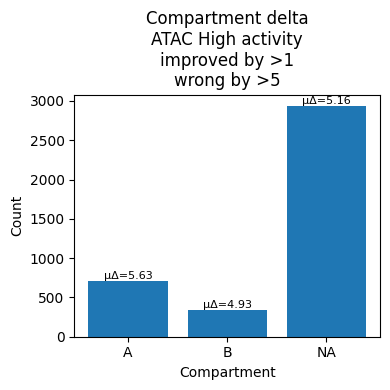

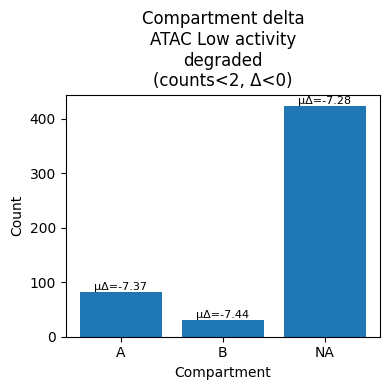

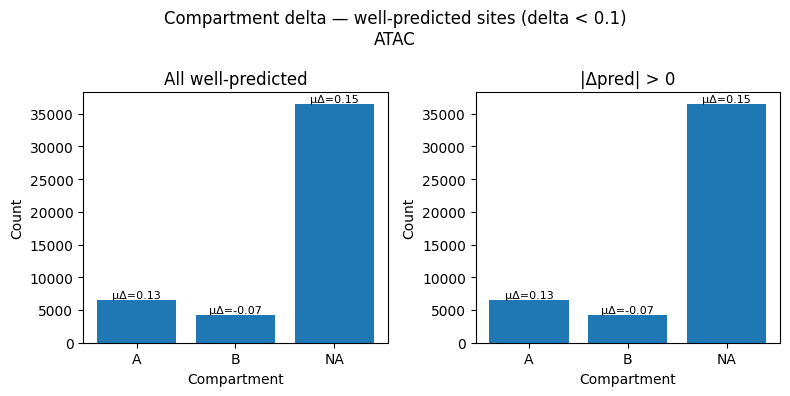

CAGE - problematic positions (delta > 0.5): 140
CAGE - well-predicted positions (delta < 0.1): 340
['NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'NA', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 

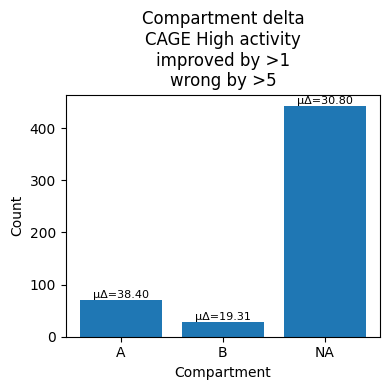

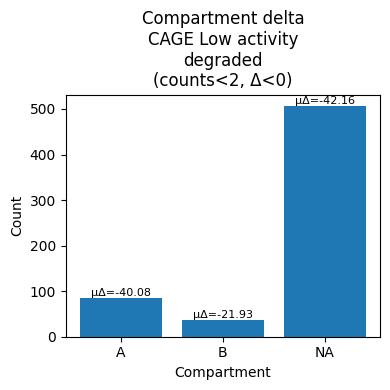

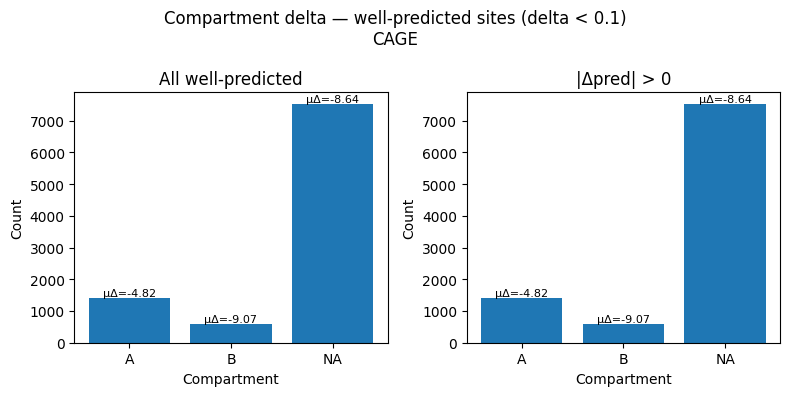

In [4]:
for data_type_idx, data_type in enumerate(['atac', 'cage']):
    delta_between_models = np.nan_to_num(np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin']) - np.array(metrics_dict[model_identifiers[1]][data_type]['pearson_per_bin']),nan=0)
    y = np.nan_to_num(np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin_methylation']), nan=0)
    target_values_high_counts = metrics_dict[model_identifiers[0]][data_type]['target_values_high_counts']
    prediction_values_high_counts_baseline = metrics_dict[model_identifiers[1]][data_type]['prediction_values_high_counts']
    prediction_values_high_counts_conditioned = metrics_dict[model_identifiers[0]][data_type]['prediction_values_high_counts']
    x = delta_between_models
    pearson_correlation = pearsonr(x, y)[0]
    axs_differential[data_type_idx, 0].hexbin(
        x = x,
        y = y,
        gridsize=20,
        bins='log',
    )
    axs_differential[data_type_idx, 0].set_xlabel(f'Pearson per bin delta\n{model_identifiers[0]} - {model_identifiers[1]}')
    axs_differential[data_type_idx, 0].set_ylabel(f'Pearson per bin methylation\n{model_identifiers[0]}')
    axs_differential[data_type_idx, 0].set_title(f'Pearson per bin methylation\nvs delta\n{data_type.upper()}')
    axs_differential[data_type_idx, 0].text(0.05, 0.95, f'Pearson corr: {pearson_correlation:.3f}', transform=axs_differential[data_type_idx, 0].transAxes, verticalalignment='top')
    x = np.nan_to_num(np.array(metrics_dict[model_identifiers[1]][data_type]['pearson_per_bin']), nan=0)
    y = np.nan_to_num(np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin_methylation']), nan=0)
    axs_differential[data_type_idx, 1].hexbin(
        x = x,
        y = y,
        gridsize=20,
        bins='log',
    )
    pearson_correlation = pearsonr(x, y)[0]
    axs_differential[data_type_idx, 1].set_xlabel(f'Pearson per bin\n{model_identifiers[1]}')
    axs_differential[data_type_idx, 1].set_ylabel(f'Pearson per bin methylation\n{model_identifiers[0]}')
    axs_differential[data_type_idx, 1].set_title(f'Pearson per bin methylation\nvs {model_identifiers[1]}\n{data_type.upper()}')
    axs_differential[data_type_idx, 1].text(0.05, 0.95, f'Pearson corr: {pearson_correlation:.3f}', transform=axs_differential[data_type_idx, 1].transAxes, verticalalignment='top')

    # Third subplot: scatter plot for problematic positions
    problematic_mask = delta_between_models > high_delta_threshold
    well_predicted_mask = delta_between_models < low_delta_threshold
    print(f"{data_type.upper()} - problematic positions (delta > {high_delta_threshold}): {problematic_mask.sum()}")
    print(f"{data_type.upper()} - well-predicted positions (delta < {low_delta_threshold}): {well_predicted_mask.sum()}")
    
    # Flatten targets and predictions for problematic positions
    targets_problematic = target_values_high_counts[:, problematic_mask].flatten()
    preds_problematic_baseline = prediction_values_high_counts_baseline[:, problematic_mask].flatten()
    preds_problematic_conditioned = prediction_values_high_counts_conditioned[:, problematic_mask].flatten()
    n_positions = problematic_mask.sum()
    n_tasks = target_values_high_counts.shape[0]
    task_indices = np.repeat(np.arange(n_tasks), n_positions)
    position_indices = np.tile(np.arange(n_positions), n_tasks)

    high_count_loci = metrics_dict[model_identifiers[0]][data_type]['high_count_loci']
    problematic_loci_idx = np.where(problematic_mask)[0]

    dataset_path_for_mappings = atlas_folder / model_identifiers[0] / "predictions.h5"
    dataset_for_mappings = BaseHDF5Dataset(dataset_path_for_mappings, datasets={'tracks','predictions'}, return_specifiers=True)
    io_mappings_for_compartments = dataset_for_mappings.get_io_mappings_df()
    task_to_cell_type = (
        io_mappings_for_compartments[io_mappings_for_compartments['data_type'] == f'{data_type.upper()}-seq']
        ['methylation_files'].str.strip("[]'").tolist()
    )

    pred_compartments = [
        query_compartment(
            chrom=high_count_loci[problematic_loci_idx[position_indices[i]]][0],
            position=high_count_loci[problematic_loci_idx[position_indices[i]]][1],
            cell_type=task_to_cell_type[task_indices[i]],
        )
        for i in range(len(task_indices))
    ]

    print(pred_compartments)
    # write bed file of problematic loci
    improvements_in_counts = np.abs(preds_problematic_baseline - targets_problematic) - np.abs(preds_problematic_conditioned - targets_problematic)
    counts_logratio = np.log1p(preds_problematic_conditioned) - np.log1p(preds_problematic_baseline)
    with open(f'loci_with_big_model_improvements_{data_type}_{f"{max_samples/1000}k" if max_samples is not None else "all"}_samples.bed', 'w') as bed_file:
        for i in range(len(task_indices)):
            if improvements_in_counts[i] > 1 and np.abs(counts_logratio[i]) > 1:
                chrom = high_count_loci[problematic_loci_idx[position_indices[i]]][0]
                pos = high_count_loci[problematic_loci_idx[position_indices[i]]][1]
                active_cell_type = task_to_cell_type[task_indices[i]]
                bed_file.write(f'{chrom}\t{pos}\t{pos+1}\t{active_cell_type}\n')
    
    axs_differential[data_type_idx, 2].hexbin(
        targets_problematic,
        preds_problematic_baseline,
        gridsize=20,
        bins='log',
    )
    
    max_val = max(targets_problematic.max(), preds_problematic_baseline.max())
    axs_differential[data_type_idx, 2].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1)
    
    axs_differential[data_type_idx, 2].set_xlabel('True counts')
    axs_differential[data_type_idx, 2].set_ylabel(f'Predicted counts\nunconditioned')
    axs_differential[data_type_idx, 2].set_title(f'Predictions at problematic sites\n{data_type.upper()} (delta > {high_delta_threshold})')
    axs_differential[data_type_idx, 2].text(0.05, 0.95, 
                                            f'N sites: {problematic_mask.sum()}\nN points: {len(targets_problematic)}', 
                                            transform=axs_differential[data_type_idx, 2].transAxes, 
                                            verticalalignment='top')
    
    axs_differential[data_type_idx, 3].hexbin(
        targets_problematic,
        preds_problematic_conditioned-preds_problematic_baseline,
        gridsize=20,
        bins='log',
    )

    max_val = max(targets_problematic.max(), preds_problematic_conditioned.max())

    axs_differential[data_type_idx, 3].set_xlabel('True counts')
    axs_differential[data_type_idx, 3].set_ylabel(f'Predicted counts\nconditioned - unconditioned')
    axs_differential[data_type_idx, 3].set_title(f'Predictions at problematic sites\n{data_type.upper()} (delta > {high_delta_threshold})')
    axs_differential[data_type_idx, 3].text(0.05, 0.95, 
                                            f'N sites: {problematic_mask.sum()}\nN points: {len(targets_problematic)}', 
                                            transform=axs_differential[data_type_idx, 3].transAxes, 
                                            verticalalignment='top')
    
    # Barplot: bar height = count per compartment, annotation = mean prediction delta
    pred_compartments_arr = np.array(pred_compartments)
    pred_delta = preds_problematic_conditioned - preds_problematic_baseline
    delta_filter = np.abs(pred_delta) > 0.0

    compartment_labels = ['A', 'B', 'NA']
    compartment_counts = [(delta_filter & (pred_compartments_arr == label)).sum() for label in compartment_labels]
    compartment_means = [
        pred_delta[delta_filter & (pred_compartments_arr == label)].mean()
        if (delta_filter & (pred_compartments_arr == label)).any() else 0.0
        for label in compartment_labels
    ]

    axs_differential[data_type_idx, 4].bar(compartment_labels, compartment_counts)
    axs_differential[data_type_idx, 4].set_xlabel('Compartment')
    axs_differential[data_type_idx, 4].set_ylabel('Count')
    axs_differential[data_type_idx, 4].set_title(f'Prediction delta by compartment\n{data_type.upper()} (|delta| > 0)')

    for i, (label, n, mean) in enumerate(zip(compartment_labels, compartment_counts, compartment_means)):
        axs_differential[data_type_idx, 4].text(
            i, n, f'μΔ={mean:.2f}', ha='center', va='bottom', fontsize=8,
        )

    # Fifth subplot: Stretch enhancer enrichment
    stretch_enhancer_flags = np.array(metrics_dict[model_identifiers[0]][data_type]['stretch_enhancer_found'])
    print(stretch_enhancer_flags)

    stretch_in_problematic = stretch_enhancer_flags[problematic_mask]
    stretch_in_well_predicted = stretch_enhancer_flags[well_predicted_mask]

    prop_problematic = stretch_in_problematic.mean()
    prop_well_predicted = stretch_in_well_predicted.mean()

    enrichment = prop_problematic / prop_well_predicted if prop_well_predicted > 0 else np.inf

    categories = ['Problematic\n(delta > {:.1f})'.format(high_delta_threshold), 
                'Well-predicted\n(delta < {:.1f})'.format(low_delta_threshold)]
    proportions = [prop_problematic, prop_well_predicted]
    counts = [stretch_in_problematic.sum(), stretch_in_well_predicted.sum()]
    totals = [problematic_mask.sum(), well_predicted_mask.sum()]

    bars = axs_differential[data_type_idx, 5].bar(categories, proportions, color=['red', 'green'], alpha=0.7)
    axs_differential[data_type_idx, 5].set_ylabel('Proportion in stretch enhancers')
    axs_differential[data_type_idx, 5].set_title(f'Stretch enhancer enrichment\n{data_type.upper()}')
    axs_differential[data_type_idx, 5].set_ylim(0, max(proportions) * 1.2)

    for i, (bar, prop, count, total) in enumerate(zip(bars, proportions, counts, totals)):
        axs_differential[data_type_idx, 5].text(
            bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{prop:.2%}\n({count}/{total})',
            ha='center', va='bottom', fontsize=9
        )

    axs_differential[data_type_idx, 5].text(
        0.5, 0.95,
        f'Enrichment: {enrichment:.2f}×',
        transform=axs_differential[data_type_idx, 5].transAxes,
        ha='center', va='top', fontsize=10, fontweight='bold'
    )

    print(f"{data_type.upper()} - Stretch enhancer enrichment:")
    print(f"  Problematic sites: {prop_problematic:.2%} ({stretch_in_problematic.sum()}/{problematic_mask.sum()})")
    print(f"  Well-predicted sites: {prop_well_predicted:.2%} ({stretch_in_well_predicted.sum()}/{well_predicted_mask.sum()})")
    print(f"  Enrichment: {enrichment:.2f}×")
    
    wrong_by = 5
    improved_by = 1
    high_activity_improved_mask = (
        ((preds_problematic_baseline - targets_problematic) < -wrong_by) & 
        ((preds_problematic_conditioned - preds_problematic_baseline) > improved_by)
    )
    low_activity_degraded_mask = (
        ((preds_problematic_baseline - targets_problematic) > wrong_by) & 
        ((preds_problematic_conditioned - preds_problematic_baseline) < -improved_by)
    )

    for split_mask, split_label, ax_col in [
        (high_activity_improved_mask, f'High activity\nimproved by >{improved_by}\nwrong by >{wrong_by}', axs_differential[data_type_idx, 4]),
        (low_activity_degraded_mask,  f'Low activity\ndegraded\n(counts<2, Δ<0)',   axs_differential[data_type_idx, 4]),
    ]:
        pred_compartments_split = pred_compartments_arr[split_mask]
        pred_delta_split = pred_delta[split_mask]

        compartment_counts_split = [(pred_compartments_split == label).sum() for label in compartment_labels]
        compartment_means_split = [
            pred_delta_split[pred_compartments_split == label].mean() 
            if (pred_compartments_split == label).any() else 0.0
            for label in compartment_labels
        ]

        fig_split, ax_split = plt.subplots(1, 1, figsize=(4, 4))
        ax_split.bar(compartment_labels, compartment_counts_split)
        ax_split.set_xlabel('Compartment')
        ax_split.set_ylabel('Count')
        ax_split.set_title(f'Compartment delta\n{data_type.upper()} {split_label}')
        for i, (label, n, mean) in enumerate(zip(compartment_labels, compartment_counts_split, compartment_means_split)):
            ax_split.text(i, n, f'μΔ={mean:.2f}', ha='center', va='bottom', fontsize=8)
        plt.tight_layout()
        plt.show()

    # Compartment barplot for well-predicted sites
    targets_well = target_values_high_counts[:, well_predicted_mask].flatten()
    preds_well_baseline = prediction_values_high_counts_baseline[:, well_predicted_mask].flatten()
    preds_well_conditioned = prediction_values_high_counts_conditioned[:, well_predicted_mask].flatten()
    n_positions_well = well_predicted_mask.sum()
    task_indices_well = np.repeat(np.arange(n_tasks), n_positions_well)
    position_indices_well = np.tile(np.arange(n_positions_well), n_tasks)
    well_predicted_loci_idx = np.where(well_predicted_mask)[0]

    pred_compartments_well = [
        query_compartment(
            chrom=high_count_loci[well_predicted_loci_idx[position_indices_well[i]]][0],
            position=high_count_loci[well_predicted_loci_idx[position_indices_well[i]]][1],
            cell_type=task_to_cell_type[task_indices_well[i]],
        )
        for i in range(len(task_indices_well))
    ]
    pred_compartments_well_arr = np.array(pred_compartments_well)
    pred_delta_well = preds_well_conditioned - preds_well_baseline

    fig_well, axs_well = plt.subplots(1, 2, figsize=(8, 4))
    fig_well.suptitle(f'Compartment delta — well-predicted sites (delta < {low_delta_threshold})\n{data_type.upper()}')

    for ax, (split_mask_well, split_label_well) in zip(axs_well, [
        (np.ones(len(pred_delta_well), dtype=bool), 'All well-predicted'),
        (
            (np.abs(pred_delta_well) > 0),
            '|Δpred| > 0',
        ),
    ]):
        comp_counts = [
            (split_mask_well & (pred_compartments_well_arr == label)).sum()
            for label in compartment_labels
        ]
        comp_means = [
            pred_delta_well[split_mask_well & (pred_compartments_well_arr == label)].mean()
            if (split_mask_well & (pred_compartments_well_arr == label)).any() else 0.0
            for label in compartment_labels
        ]
        ax.bar(compartment_labels, comp_counts)
        ax.set_xlabel('Compartment')
        ax.set_ylabel('Count')
        ax.set_title(split_label_well)
        for i, (label, n, mean) in enumerate(zip(compartment_labels, comp_counts, comp_means)):
            ax.text(i, n, f'μΔ={mean:.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

(42, 768000) 0.0 1.0 (63, 768000) 0.0 795.064


/tmp/ipykernel_3776701/3705439988.py:65: RuntimeWarning: invalid value encountered in divide
  return num / denom
/tmp/ipykernel_3776701/833732426.py:19: RuntimeWarning: Mean of empty slice
  reps_axs[0,0].hist(np.abs(conditional_correlations), bins=50, alpha=0.5, label=f'conditional rep\nmean: {np.nanmean(np.abs(conditional_correlations)):.3f}')
/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/matplotlib/axes/_axes.py:6834: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/matplotlib/axes/_axes.py:6835: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

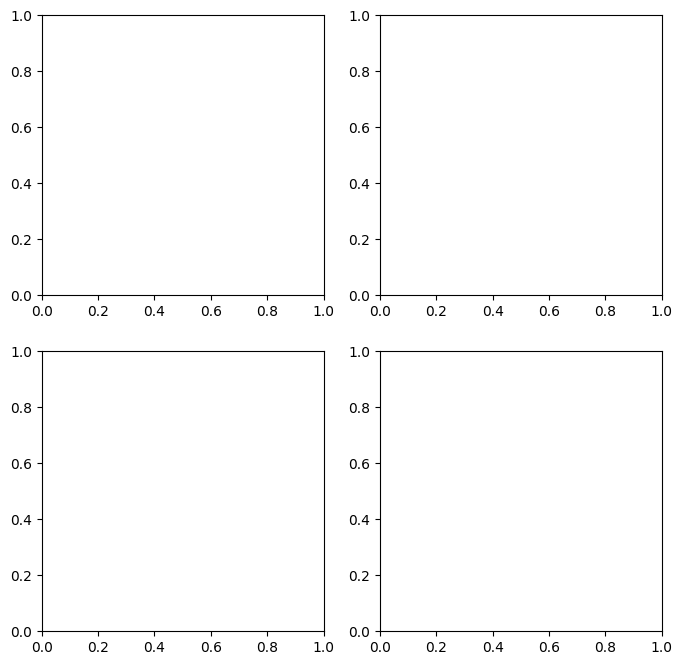

In [5]:
active_sites = np.where(all_targets[atac_channels,:].max(axis=0) > min_bin_counts_crosstask['atac'])[0]

active_site_target_cov = all_targets[atac_channels][:,active_sites].var(axis=0) / (all_targets[atac_channels][:,active_sites].mean(axis=0)+1e-5)
active_site_methylation_cov = all_methylations[:,active_sites].var(axis=0) / (all_methylations[:,active_sites].mean(axis=0)+1e-5)
print(all_methylations.shape,all_methylations.min(),all_methylations.max(),all_targets.shape,all_targets.min(),all_targets.max())
# fig, ax = plt.subplots(figsize=(6,4))
# ax.scatter(active_site_target_cov, active_site_methylation_cov, alpha=0.5)
# ax.loglog()
# fig.show()
reps_fig, reps_axs = plt.subplots(2,2, figsize=(8,8))
conditional_correlations = rowwise_corrcoef(all_conditional_seq_reps[:,active_sites], all_cpg_densities[active_sites])
unconditional_correlations = rowwise_corrcoef(all_unconditional_seq_reps[:,active_sites], all_cpg_densities[active_sites])
conditional_means = all_conditional_seq_reps[:,active_sites].mean(axis=1)
unconditional_means = all_unconditional_seq_reps[:,active_sites].mean(axis=1)
conditional_variances = all_conditional_seq_reps[:,active_sites].var(axis=1)
unconditional_variances = all_unconditional_seq_reps[:,active_sites].var(axis=1)
conditional_fve = (np.abs(conditional_correlations) * conditional_variances).sum() / conditional_variances.sum()
unconditional_fve = (np.abs(unconditional_correlations) * unconditional_variances).sum() / unconditional_variances.sum()
reps_axs[0,0].hist(np.abs(conditional_correlations), bins=50, alpha=0.5, label=f'conditional rep\nmean: {np.nanmean(np.abs(conditional_correlations)):.3f}')
reps_axs[0,0].hist(np.abs(unconditional_correlations), bins=50, alpha=0.5, label=f'unconditional rep\nmean: {np.nanmean(np.abs(unconditional_correlations)):.3f}')
reps_axs[0,0].legend()
reps_axs[0,0].set_title("Embeddings activations across active sites\ncorrelation with CpG density")
reps_axs[0,0].set_xlabel('abs(correlation with CpG density)')
reps_axs[0,0].set_ylabel('count')
# reps_axs[0,1].scatter(active_site_methylation_cov,active_site_target_cov, alpha=0.5)
reps_axs[1,0].scatter(conditional_correlations,conditional_variances, color='purple', alpha=0.5, label=f'conditional') #rep\nmean: {np.nanmean(conditional_variances):.3f}
reps_axs[1,0].scatter(unconditional_correlations,unconditional_variances, color='green', alpha=0.5, label=f'unconditional') # rep\nmean: {np.nanmean(unconditional_variances):.3f}'
reps_axs[1,0].legend()
reps_axs[1,0].legend()
reps_axs[1,0].set_xlabel('correlation with CpG density\nacross test set active sites')
reps_axs[1,0].set_ylabel('feature variance\nacross test set active sites')
ax = reps_axs[1,0]  # your scatter panel
divider = make_axes_locatable(ax)
ax_histx = divider.append_axes("top", 0.6, pad=0.1, sharex=ax)
ax_histy = divider.append_axes("right", 0.6, pad=0.1, sharey=ax)
ax_histx.tick_params(labelbottom=False)
ax_histy.tick_params(labelleft=False)
ax_histx.set_yscale('log')
ax_histy.set_xscale('log')
ax_histx.set_title("Feature variance vs correlation\nwith CpG density")

ax_histx.hist(conditional_correlations, bins=np.arange(-0.5,1,0.03), alpha=0.5, color='purple')
ax_histx.hist(unconditional_correlations, bins=np.arange(-0.5,1,0.03), alpha=0.5, color='green')
ax_histy.hist(conditional_variances, bins=np.arange(0,100,2), alpha=0.5, color='purple', orientation='horizontal')
ax_histy.hist(unconditional_variances, bins=np.arange(0,100,2), alpha=0.5, color='green', orientation='horizontal')
# reps_axs[1,0].scatter(active_site_methylation_cov, all_conditional_seq_reps[:, active_sites].mean(axis=0), alpha=0.5, label=f'conditional rep\nmean: {np.nanmean(all_conditional_seq_reps):.3f}')
# reps_axs[1,0].scatter(active_site_methylation_cov, all_unconditional_seq_reps[:, active_sites].mean(axis=0), alpha=0.5, label=f'unconditional rep\nmean: {np.nanmean(all_unconditional_seq_reps):.3f}')
# reps_axs[1,0].legend()
# Conditional
cond_order = np.argsort(conditional_variances)[::-1]
cond_cumvar_frac = np.cumsum(conditional_variances[cond_order]) / conditional_variances.sum() * 100
cond_cum_explained = np.cumsum((conditional_correlations[cond_order]**2 * conditional_variances[cond_order])) / conditional_variances.sum() * 100

# Unconditional
uncond_order = np.argsort(unconditional_variances)[::-1]
uncond_cumvar_frac = np.cumsum(unconditional_variances[uncond_order]) / unconditional_variances.sum() * 100
uncond_cum_explained = np.cumsum((unconditional_correlations[uncond_order]**2 * unconditional_variances[uncond_order])) / unconditional_variances.sum() * 100

ax = reps_axs[1,1]
ax.plot(cond_cumvar_frac, cond_cum_explained, color='purple', label='conditional')
ax.plot(uncond_cumvar_frac, uncond_cum_explained, color='green', label='unconditional')
ax.set_xlabel('% total embedding variance explained\nby top N features (ranked by variance)')
ax.set_ylabel('% total variance explained\nby CpG density')
ax.set_title('Cumulative ranked feature variance\nexplained by CpG density')
ax.legend()
# cond_order = np.argsort(conditional_variances)[::-1]
# cond_cum_explained = np.cumsum((conditional_correlations * conditional_variances)[cond_order]) / conditional_variances.sum()

# uncond_order = np.argsort(unconditional_variances)[::-1]
# uncond_cum_explained = np.cumsum((unconditional_correlations * unconditional_variances)[uncond_order]) / unconditional_variances.sum()

# dims = np.arange(1, len(conditional_variances) + 1)

# reps_axs[1,1].plot(dims, cond_cum_explained * 100, color='tab:blue', label='conditional')
# reps_axs[1,1].plot(dims, uncond_cum_explained * 100, color='tab:orange', label='unconditional')
# reps_axs[1,1].set_xlabel('# dimensions (ranked by variance)')
# reps_axs[1,1].set_ylabel('% cumulative variance\nexplained by CpG density')
# reps_axs[1,1].set_title('Cumulative variance explained\nby CpG density across dimensions')
# reps_axs[1,1].legend()
# low_target_var_conditional = all_conditional_seq_reps[:, active_sites][:, active_site_methylation_cov < .01].mean(axis=0).mean()
# high_target_var_conditional = all_conditional_seq_reps[:, active_sites][:, active_site_methylation_cov >= .01].mean(axis=0).mean()
# low_target_var_unconditional = all_unconditional_seq_reps[:, active_sites][:, active_site_methylation_cov < .01].mean(axis=0).mean()
# high_target_var_unconditional = all_unconditional_seq_reps[:, active_sites][:, active_site_methylation_cov >= .01].mean(axis=0).mean()
# reps_axs[0,1].set_title("Fraction variance explained\nconditional vs unconditional rep")
# reps_axs[0,1].bar(
#     ['conditional%\n variance explained', 'unconditional %\nvariance explained'],
#     [100*conditional_fve, 100*unconditional_fve],
#     alpha=0.5,
# )
# reps_axs[0,1].set_ylabel("% variance of rep across active sites\nexplained by correlation with CpG density")
# reps_axs[1,1].scatter(active_site_target_cov, all_conditional_seq_reps[:, active_sites].mean(axis=0), alpha=0.5, label=f'conditional rep\nmean: {np.nanmean(all_conditional_seq_reps):.3f}')
# reps_axs[1,1].scatter(active_site_target_cov, all_unconditional_seq_reps[:, active_sites].mean(axis=0), alpha=0.5, label=f'unconditional rep\nmean: {np.nanmean(all_unconditional_seq_reps):.3f}')
# reps_axs[0,1].legend()
reps_fig.tight_layout()

In [ ]:
# # Calculate coverage statistics
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))

# # Plot 1: Number of regions per chromosome (before merging)
# region_counts = [len(chr_regions.get(chrom, [])) for chrom in chr_order]
# merged_counts = [len(chr_merged.get(chrom, [])) for chrom in chr_order]

# x = np.arange(len(chr_order))
# width = 0.35
# ax1.bar(x - width/2, region_counts, width, label='Original', color='steelblue', alpha=0.7)
# ax1.bar(x + width/2, merged_counts, width, label='After merge', color='coral', alpha=0.7)
# ax1.set_xticks(range(len(chr_order)))
# ax1.set_xticklabels(chr_order, rotation=45, ha='right')
# ax1.set_ylabel('Number of Regions')
# ax1.set_title('Region Count per Chromosome')
# ax1.legend()
# ax1.grid(axis='y', alpha=0.3)

# # Plot 2: Total bp coverage per chromosome (after merging)
# coverage_bp = []
# coverage_pct = []
# for chrom in chr_order:
#     total_bp = sum(end - start for start, end in chr_merged.get(chrom, []))
#     coverage_bp.append(total_bp / 1e6)  # Convert to Mb
#     coverage_pct.append(100 * total_bp / chr_lengths[chrom])

# ax2_twin = ax2.twinx()

# bars = ax2.bar(x, coverage_bp, color='forestgreen', alpha=0.7, label='Coverage (Mb)')
# line = ax2_twin.plot(x, coverage_pct, 'o-', color='darkviolet', linewidth=2, 
#                     markersize=4, label='Coverage (%)')

# ax2.set_xticks(range(len(chr_order)))
# ax2.set_xticklabels(chr_order, rotation=45, ha='right')
# ax2.set_ylabel('Coverage (Mb)', color='forestgreen')
# ax2_twin.set_ylabel('Coverage (%)', color='darkviolet')
# ax2.set_title('Genomic Coverage per Chromosome (Merged Intervals)')
# ax2.grid(axis='y', alpha=0.3)

# lines1, labels1 = ax2.get_legend_handles_labels()
# lines2, labels2 = ax2_twin.get_legend_handles_labels()
# ax2_twin.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# # Plot 3: Overlap statistics
# overlap_ratios = []
# for chrom in chr_order:
#     original_bp = sum(end - start for start, end in chr_regions.get(chrom, []))
#     merged_bp = sum(end - start for start, end in chr_merged.get(chrom, []))
#     if original_bp > 0:
#         overlap_ratios.append(100 * (1 - merged_bp / original_bp))
#     else:
#         overlap_ratios.append(0)

# ax3.bar(x, overlap_ratios, color='tomato', alpha=0.7)
# ax3.set_xticks(range(len(chr_order)))
# ax3.set_xticklabels(chr_order, rotation=45, ha='right')
# ax3.set_ylabel('Overlap (%)')
# ax3.set_title('Percentage of Coverage Lost to Overlaps')
# ax3.grid(axis='y', alpha=0.3)

# plt.tight_layout()
# fig.show()

['B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B',

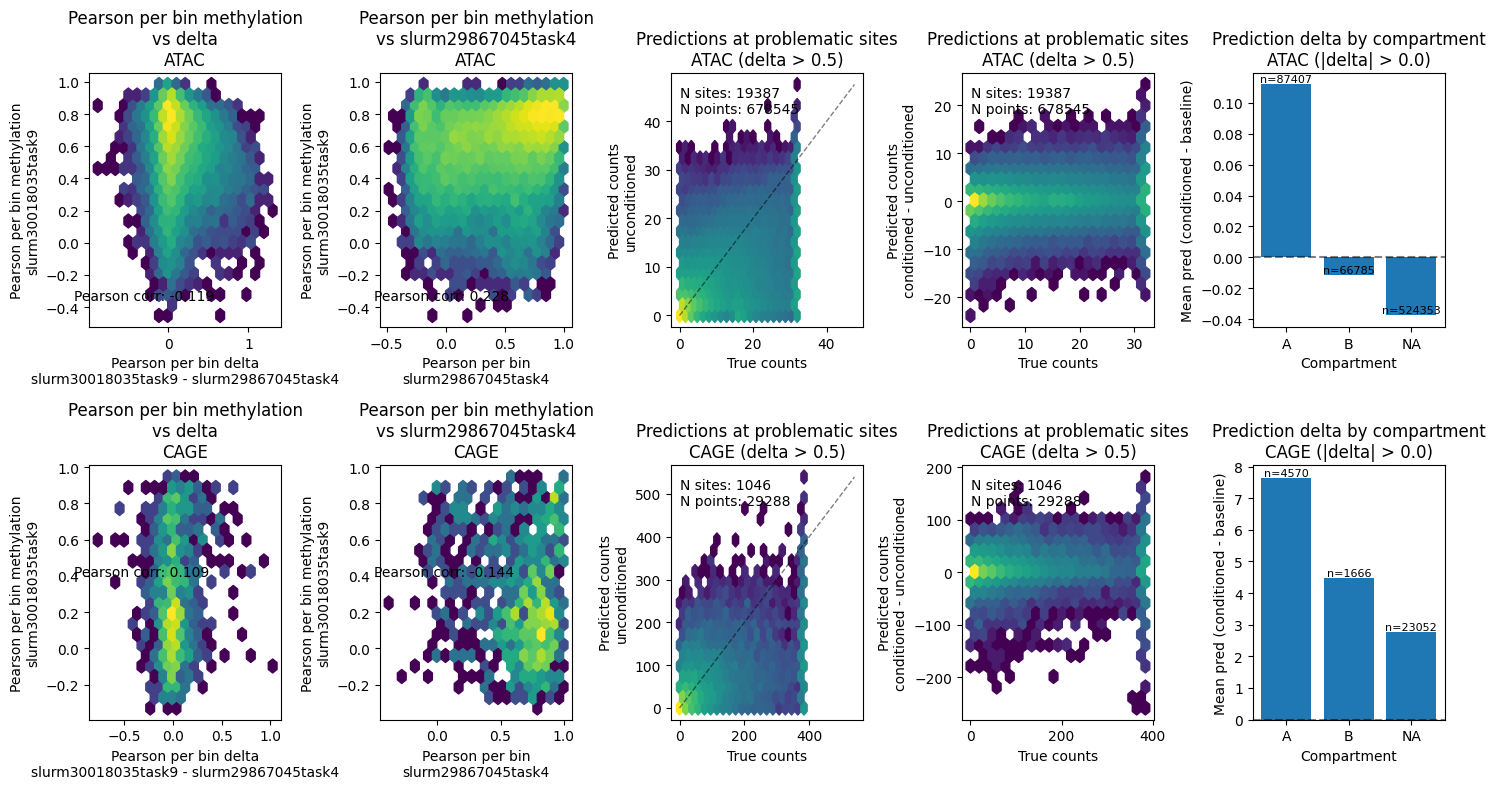

In [ ]:
fig_differential, axs_differential = plt.subplots(2,5, figsize=(15,8))
delta_threshold = 0.5
for data_type_idx, data_type in enumerate(['atac', 'cage']):
    delta_between_models = np.nan_to_num(
        np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin'])
        - np.array(metrics_dict[model_identifiers[1]][data_type]['pearson_per_bin'])
    )
        # np.arctanh(
        #     np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin'])
        #     )
        # - np.arctanh(
        #     np.array(metrics_dict[model_identifiers[1]][data_type]['pearson_per_bin'])
        #     )
        # ,nan=0)
    y = np.nan_to_num(np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin_methylation']), nan=0)
    target_values_high_counts = metrics_dict[model_identifiers[0]][data_type]['target_values_high_counts']
    prediction_values_high_counts_baseline = metrics_dict[model_identifiers[1]][data_type]['prediction_values_high_counts']
    prediction_values_high_counts_conditioned = metrics_dict[model_identifiers[0]][data_type]['prediction_values_high_counts']
    x = delta_between_models
    pearson_correlation = pearsonr(x, y)[0]
    axs_differential[data_type_idx, 0].hexbin(
        x = x,
        y = y,
        gridsize=20,
        bins='log',
    )
    axs_differential[data_type_idx, 0].set_xlabel(f'Pearson per bin delta\n{model_identifiers[0]} - {model_identifiers[1]}')
    axs_differential[data_type_idx, 0].set_ylabel(f'Pearson per bin methylation\n{model_identifiers[0]}')
    axs_differential[data_type_idx, 0].set_title(f'Pearson per bin methylation\nvs delta\n{data_type.upper()}')
    axs_differential[data_type_idx, 0].text(0.05, 0.95, f'Pearson corr: {pearson_correlation:.3f}', transform=axs[data_type_idx, 0].transAxes, verticalalignment='top')
    x = np.nan_to_num(np.array(metrics_dict[model_identifiers[1]][data_type]['pearson_per_bin']), nan=0)
    y = np.nan_to_num(np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin_methylation']), nan=0)
    axs_differential[data_type_idx, 1].hexbin(
        x = x,
        y = y,
        gridsize=20,
        bins='log',
    )
    pearson_correlation = pearsonr(x, y)[0]
    axs_differential[data_type_idx, 1].set_xlabel(f'Pearson per bin\n{model_identifiers[1]}')
    axs_differential[data_type_idx, 1].set_ylabel(f'Pearson per bin methylation\n{model_identifiers[0]}')
    axs_differential[data_type_idx, 1].set_title(f'Pearson per bin methylation\nvs {model_identifiers[1]}\n{data_type.upper()}')
    axs_differential[data_type_idx, 1].text(0.05, 0.95, f'Pearson corr: {pearson_correlation:.3f}', transform=axs[data_type_idx, 1].transAxes, verticalalignment='top')

    # Third subplot: scatter plot for problematic positions
    problematic_mask = delta_between_models < delta_threshold
    
    # Flatten targets and predictions for problematic positions
    targets_problematic = target_values_high_counts[:, problematic_mask].flatten()
    preds_problematic_baseline = prediction_values_high_counts_baseline[:, problematic_mask].flatten()
    n_positions = problematic_mask.sum()
    n_tasks = target_values_high_counts.shape[0]
    task_indices = np.repeat(np.arange(n_tasks), n_positions)
    position_indices = np.tile(np.arange(n_positions), n_tasks)

    # Use high_count_loci from the FIRST model (they should be the same across models
    # since high_counts_indices depends on targets which are identical)
    high_count_loci = metrics_dict[model_identifiers[0]][data_type]['high_count_loci']
    problematic_loci_idx = np.where(problematic_mask)[0]

    # Map relative task index -> methylation cell type name
    # Need io_mappings from one of the models - reload to avoid stale reference
    dataset_path_for_mappings = atlas_folder / model_identifiers[0] / f"fold{fold}{checkpoint_type}" / "predictions.h5"
    dataset_for_mappings = BaseHDF5Dataset(dataset_path_for_mappings, datasets={'tracks','predictions'}, return_specifiers=True)
    io_mappings_for_compartments = dataset_for_mappings.get_io_mappings_df()
    task_to_cell_type = (
        io_mappings_for_compartments[io_mappings_for_compartments['data_type'] == f'{data_type.upper()}-seq']
        ['methylation_files'].str.strip("[]'").tolist()
    )

    pred_compartments = [
        query_compartment(
            chrom=high_count_loci[problematic_loci_idx[position_indices[i]]][0],
            position=high_count_loci[problematic_loci_idx[position_indices[i]]][1],
            cell_type=task_to_cell_type[task_indices[i]],
        )
        for i in range(len(task_indices))
    ]

    print(pred_compartments)
    
    # Color by activity level (median split)
    median_target = np.median(targets_problematic)
    # colors = ['blue' if t < median_target else 'red' for t in targets_problematic]
    
    axs_differential[data_type_idx, 2].hexbin(
        targets_problematic,
        preds_problematic_baseline,
        gridsize=20,
        bins='log',
    )
    
    # Add diagonal line
    max_val = max(targets_problematic.max(), preds_problematic_baseline.max())
    axs_differential[data_type_idx, 2].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1)
    
    axs_differential[data_type_idx, 2].set_xlabel('True counts')
    axs_differential[data_type_idx, 2].set_ylabel(f'Predicted counts\nunconditioned')
    axs_differential[data_type_idx, 2].set_title(f'Predictions at problematic sites\n{data_type.upper()} (delta > {delta_threshold})')
    axs_differential[data_type_idx, 2].text(0.05, 0.95, 
                                            f'N sites: {problematic_mask.sum()}\nN points: {len(targets_problematic)}', 
                                            transform=axs_differential[data_type_idx, 2].transAxes, 
                                            verticalalignment='top')
    
    preds_problematic_conditioned = prediction_values_high_counts_conditioned[:, problematic_mask].flatten()
    axs_differential[data_type_idx, 3].hexbin(
        targets_problematic,
        preds_problematic_conditioned-preds_problematic_baseline,
        gridsize=20,
        bins='log',
    )

    # Add diagonal line
    max_val = max(targets_problematic.max(), preds_problematic_conditioned.max())
    # axs_differential[data_type_idx, 3].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1)

    axs_differential[data_type_idx, 3].set_xlabel('True counts')
    axs_differential[data_type_idx, 3].set_ylabel(f'Predicted counts\nconditioned - unconditioned')
    axs_differential[data_type_idx, 3].set_title(f'Predictions at problematic sites\n{data_type.upper()} (delta > {delta_threshold})')
    axs_differential[data_type_idx, 3].text(0.05, 0.95, 
                                            f'N sites: {problematic_mask.sum()}\nN points: {len(targets_problematic)}', 
                                            transform=axs_differential[data_type_idx, 3].transAxes, 
                                            verticalalignment='top')
    
    # Barplot of mean prediction delta by compartment (filtered)
    pred_compartments_arr = np.array(pred_compartments)
    pred_delta = preds_problematic_conditioned - preds_problematic_baseline
    pred_delta_min = 0.0
    delta_filter = np.abs(pred_delta) > pred_delta_min

    compartment_labels = ['A', 'B', 'NA']
    compartment_means = [pred_delta[delta_filter & (pred_compartments_arr == label)].mean() for label in compartment_labels]
    compartment_ns = [(delta_filter & (pred_compartments_arr == label)).sum() for label in compartment_labels]

    axs_differential[data_type_idx, 4].bar(compartment_labels, compartment_means)
    axs_differential[data_type_idx, 4].set_xlabel('Compartment')
    axs_differential[data_type_idx, 4].set_ylabel('Mean pred (conditioned - baseline)')
    axs_differential[data_type_idx, 4].set_title(f'Prediction delta by compartment\n{data_type.upper()} (|delta| > {pred_delta_min})')
    axs_differential[data_type_idx, 4].axhline(0, color='black', linestyle='--', alpha=0.5)

    for i, (label, n) in enumerate(zip(compartment_labels, compartment_ns)):
        axs_differential[data_type_idx, 4].text(
            i, compartment_means[i], f'n={n}', ha='center', va='bottom', fontsize=8,
        )
plt.tight_layout()

improved by 0.25: 15888 worsened by 0.25: 291 changed by less than 0.25: 50446
ATAC - problematic positions (delta > 0.5): 6879
ATAC - well-predicted positions (delta < 0.1): 37434
['A', 'A', 'A', 'B', 'A', 'B', 'B', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'B', 'A', 'A', 'A', 'A', 'B', 'B', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'NA', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'A', 'A', 'A', 'B', 'B', 'B', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'A', 'A', 'A', 'A', 'B', 'B', 'A', 'A', 'B', 'B', 'B', 'B', 'A', 'A', 'B', 'A', 'A', 'NA', 'B', 'A', 'A', 'B', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', '

/tmp/ipykernel_3345692/2541549956.py:134: RuntimeWarning: Mean of empty slice.
  compartment_means = [pred_delta[delta_filter & (pred_compartments_arr == label)].mean() for label in compartment_labels]
/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


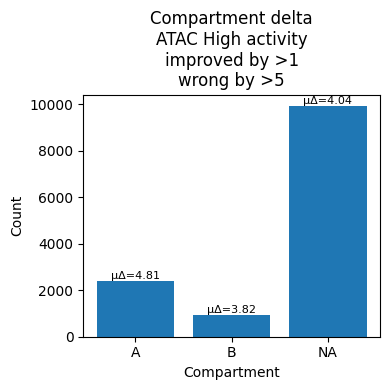

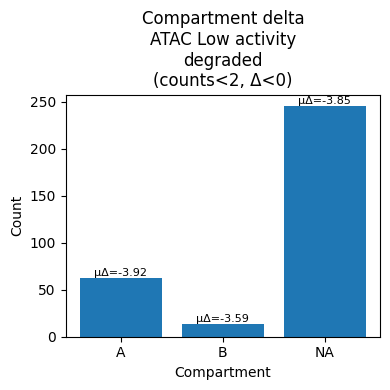

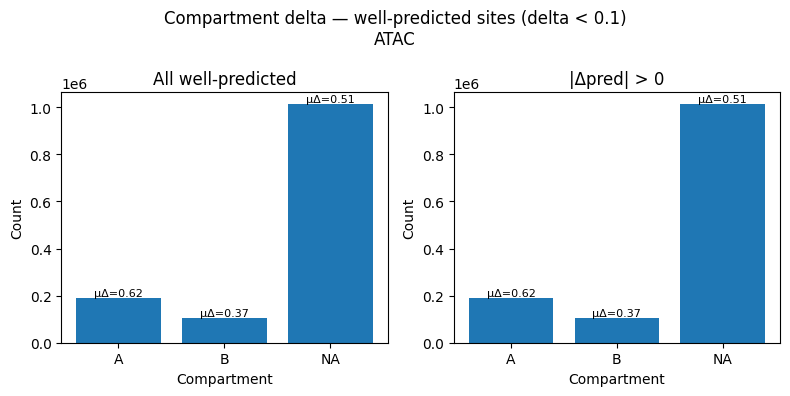

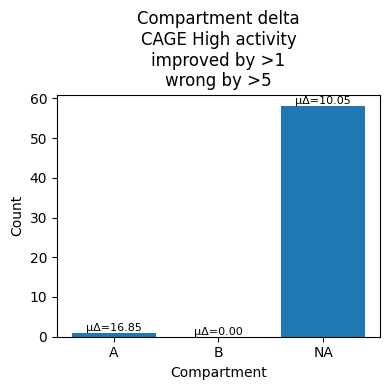

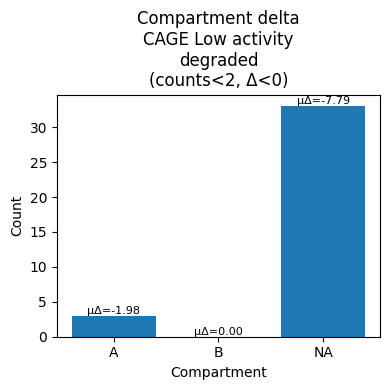

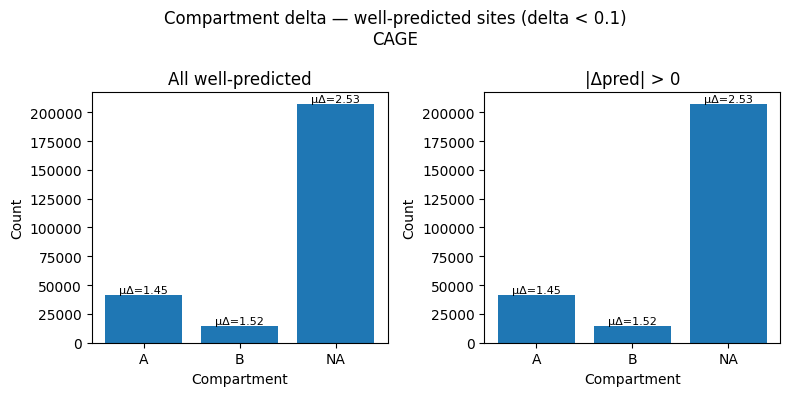

In [ ]:
for data_type_idx, data_type in enumerate(['atac', 'cage']):
    delta_between_models = np.nan_to_num(np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin']) - np.array(metrics_dict[model_identifiers[1]][data_type]['pearson_per_bin']),nan=0)
    y = np.nan_to_num(np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin_methylation']), nan=0)
    target_values_high_counts = metrics_dict[model_identifiers[0]][data_type]['target_values_high_counts']
    prediction_values_high_counts_baseline = metrics_dict[model_identifiers[1]][data_type]['prediction_values_high_counts']
    prediction_values_high_counts_conditioned = metrics_dict[model_identifiers[0]][data_type]['prediction_values_high_counts']
    x = delta_between_models
    pearson_correlation = pearsonr(x, y)[0]
    axs_differential[data_type_idx, 0].hexbin(
        x = x,
        y = y,
        gridsize=20,
        bins='log',
    )
    axs_differential[data_type_idx, 0].set_xlabel(f'Pearson per bin delta\n{model_identifiers[0]} - {model_identifiers[1]}')
    axs_differential[data_type_idx, 0].set_ylabel(f'Pearson per bin methylation\n{model_identifiers[0]}')
    axs_differential[data_type_idx, 0].set_title(f'Pearson per bin methylation\nvs delta\n{data_type.upper()}')
    axs_differential[data_type_idx, 0].text(0.05, 0.95, f'Pearson corr: {pearson_correlation:.3f}', transform=axs_differential[data_type_idx, 0].transAxes, verticalalignment='top')
    x = np.nan_to_num(np.array(metrics_dict[model_identifiers[1]][data_type]['pearson_per_bin']), nan=0)
    y = np.nan_to_num(np.array(metrics_dict[model_identifiers[0]][data_type]['pearson_per_bin_methylation']), nan=0)
    axs_differential[data_type_idx, 1].hexbin(
        x = x,
        y = y,
        gridsize=20,
        bins='log',
    )
    pearson_correlation = pearsonr(x, y)[0]
    axs_differential[data_type_idx, 1].set_xlabel(f'Pearson per bin\n{model_identifiers[1]}')
    axs_differential[data_type_idx, 1].set_ylabel(f'Pearson per bin methylation\n{model_identifiers[0]}')
    axs_differential[data_type_idx, 1].set_title(f'Pearson per bin methylation\nvs {model_identifiers[1]}\n{data_type.upper()}')
    axs_differential[data_type_idx, 1].text(0.05, 0.95, f'Pearson corr: {pearson_correlation:.3f}', transform=axs_differential[data_type_idx, 1].transAxes, verticalalignment='top')

    print(f"improved by 0.25:",np.sum(delta_between_models > 0.25),"worsened by 0.25:",np.sum(delta_between_models < -0.25),"changed by less than 0.25:",np.sum(np.abs(delta_between_models) <= 0.25))
    # Third subplot: scatter plot for problematic positions
    problematic_mask = delta_between_models > high_delta_threshold
    well_predicted_mask = delta_between_models < low_delta_threshold
    print(f"{data_type.upper()} - problematic positions (delta > {high_delta_threshold}): {problematic_mask.sum()}")
    print(f"{data_type.upper()} - well-predicted positions (delta < {low_delta_threshold}): {well_predicted_mask.sum()}")
    
    # Flatten targets and predictions for problematic positions
    targets_problematic = target_values_high_counts[:, problematic_mask].flatten()
    preds_problematic_baseline = prediction_values_high_counts_baseline[:, problematic_mask].flatten()
    preds_problematic_conditioned = prediction_values_high_counts_conditioned[:, problematic_mask].flatten()
    n_positions = problematic_mask.sum()
    n_tasks = target_values_high_counts.shape[0]
    task_indices = np.repeat(np.arange(n_tasks), n_positions)
    position_indices = np.tile(np.arange(n_positions), n_tasks)

    # Use high_count_loci from the FIRST model (they should be the same across models
    # since high_counts_indices depends on targets which are identical)
    high_count_loci = metrics_dict[model_identifiers[0]][data_type]['high_count_loci']
    problematic_loci_idx = np.where(problematic_mask)[0]

    # Map relative task index -> methylation cell type name
    # Need io_mappings from one of the models - reload to avoid stale reference
    dataset_path_for_mappings = atlas_folder / model_identifiers[0] / "predictions.h5"
    dataset_for_mappings = BaseHDF5Dataset(dataset_path_for_mappings, datasets={'tracks','predictions'}, return_specifiers=True)
    io_mappings_for_compartments = dataset_for_mappings.get_io_mappings_df()
    task_to_cell_type = (
        io_mappings_for_compartments[io_mappings_for_compartments['data_type'] == f'{data_type.upper()}-seq']
        ['methylation_files'].str.strip("[]'").tolist()
    )

    pred_compartments = [
        query_compartment(
            chrom=high_count_loci[problematic_loci_idx[position_indices[i]]][0],
            position=high_count_loci[problematic_loci_idx[position_indices[i]]][1],
            cell_type=task_to_cell_type[task_indices[i]],
        )
        for i in range(len(task_indices))
    ]

    print(pred_compartments)
    # write bed file of problematic loci
    improvements_in_counts = np.abs(preds_problematic_baseline - targets_problematic) - np.abs(preds_problematic_conditioned - targets_problematic)
    counts_logratio = np.log1p(preds_problematic_conditioned) - np.log1p(preds_problematic_baseline)
    with open(f'loci_with_big_model_improvements_{data_type}_{f"{max_samples/1000}k" if max_samples is not None else "all"}_samples.bed', 'w') as bed_file:
        for i in range(len(task_indices)):
            if improvements_in_counts[i] > 1 and np.abs(counts_logratio[i]) > 1:  # Only write loci where the conditioned model is a lot better
                chrom = high_count_loci[problematic_loci_idx[position_indices[i]]][0]
                pos = high_count_loci[problematic_loci_idx[position_indices[i]]][1]
                active_cell_type = task_to_cell_type[task_indices[i]]
                bed_file.write(f'{chrom}\t{pos}\t{pos+1}\t{active_cell_type}\n')
    
    # Color by activity level (median split)
    median_target = np.median(targets_problematic)
    # colors = ['blue' if t < median_target else 'red' for t in targets_problematic]
    
    axs_differential[data_type_idx, 2].hexbin(
        targets_problematic,
        preds_problematic_baseline,
        gridsize=20,
        bins='log',
    )
    
    # Add diagonal line
    max_val = max(targets_problematic.max(), preds_problematic_baseline.max())
    axs_differential[data_type_idx, 2].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1)
    
    axs_differential[data_type_idx, 2].set_xlabel('True counts')
    axs_differential[data_type_idx, 2].set_ylabel(f'Predicted counts\nunconditioned')
    axs_differential[data_type_idx, 2].set_title(f'Predictions at problematic sites\n{data_type.upper()} (delta > {high_delta_threshold})')
    axs_differential[data_type_idx, 2].text(0.05, 0.95, 
                                            f'N sites: {problematic_mask.sum()}\nN points: {len(targets_problematic)}', 
                                            transform=axs_differential[data_type_idx, 2].transAxes, 
                                            verticalalignment='top')
    
    axs_differential[data_type_idx, 3].hexbin(
        targets_problematic,
        preds_problematic_conditioned-preds_problematic_baseline,
        gridsize=20,
        bins='log',
    )

    # Add diagonal line
    max_val = max(targets_problematic.max(), preds_problematic_conditioned.max())
    # axs_differential[data_type_idx, 3].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1)

    axs_differential[data_type_idx, 3].set_xlabel('True counts')
    axs_differential[data_type_idx, 3].set_ylabel(f'Predicted counts\nconditioned - unconditioned')
    axs_differential[data_type_idx, 3].set_title(f'Predictions at problematic sites\n{data_type.upper()} (delta > {high_delta_threshold})')
    axs_differential[data_type_idx, 3].text(0.05, 0.95, 
                                            f'N sites: {problematic_mask.sum()}\nN points: {len(targets_problematic)}', 
                                            transform=axs_differential[data_type_idx, 3].transAxes, 
                                            verticalalignment='top')
    
    # Barplot of mean prediction delta by compartment (filtered)
    pred_compartments_arr = np.array(pred_compartments)
    pred_delta = preds_problematic_conditioned - preds_problematic_baseline
    pred_delta_threshold = 1.0
    delta_filter = np.abs(pred_delta) > pred_delta_threshold

    compartment_labels = ['A', 'B', 'NA']
    compartment_means = [pred_delta[delta_filter & (pred_compartments_arr == label)].mean() for label in compartment_labels]
    compartment_ns = [(delta_filter & (pred_compartments_arr == label)).sum() for label in compartment_labels]

    axs_differential[data_type_idx, 4].bar(compartment_labels, compartment_means)
    axs_differential[data_type_idx, 4].set_xlabel('Compartment')
    axs_differential[data_type_idx, 4].set_ylabel('Mean pred (conditioned - baseline)')
    axs_differential[data_type_idx, 4].set_title(f'Prediction delta by compartment\n{data_type.upper()} (|delta| > 1)')
    axs_differential[data_type_idx, 4].axhline(0, color='black', linestyle='--', alpha=0.5)

    for i, (label, n) in enumerate(zip(compartment_labels, compartment_ns)):
        axs_differential[data_type_idx, 4].text(
            i, compartment_means[i], f'n={n}', ha='center', va='bottom', fontsize=8,
        )

    # Fifth subplot: Stretch enhancer enrichment
    stretch_enhancer_flags = np.array(metrics_dict[model_identifiers[0]][data_type]['stretch_enhancer_found'])
    print(stretch_enhancer_flags)

    # Get stretch enhancer status for problematic and well-predicted positions
    stretch_in_problematic = stretch_enhancer_flags[problematic_mask]
    stretch_in_well_predicted = stretch_enhancer_flags[well_predicted_mask]

    # Calculate proportions
    prop_problematic = stretch_in_problematic.mean()
    prop_well_predicted = stretch_in_well_predicted.mean()

    # Calculate enrichment (fold-change)
    enrichment = prop_problematic / prop_well_predicted if prop_well_predicted > 0 else np.inf

    # Barplot: bar height = count per compartment, annotation = mean prediction delta
    pred_compartments_arr = np.array(pred_compartments)
    pred_delta = preds_problematic_conditioned - preds_problematic_baseline
    delta_filter = np.abs(pred_delta) > 0.0

    compartment_labels = ['A', 'B', 'NA']
    compartment_counts = [(delta_filter & (pred_compartments_arr == label)).sum() for label in compartment_labels]
    compartment_means = [
        pred_delta[delta_filter & (pred_compartments_arr == label)].mean()
        if (delta_filter & (pred_compartments_arr == label)).any() else 0.0
        for label in compartment_labels
    ]

    axs_differential[data_type_idx, 4].bar(compartment_labels, compartment_counts)
    axs_differential[data_type_idx, 4].set_xlabel('Compartment')
    axs_differential[data_type_idx, 4].set_ylabel('Count')
    axs_differential[data_type_idx, 4].set_title(f'Prediction delta by compartment\n{data_type.upper()} (|delta| > 0)')

    for i, (label, n, mean) in enumerate(zip(compartment_labels, compartment_counts, compartment_means)):
        axs_differential[data_type_idx, 4].text(
            i, n, f'μΔ={mean:.2f}', ha='center', va='bottom', fontsize=8,
        )

    # Fifth subplot: Stretch enhancer enrichment
    stretch_enhancer_flags = np.array(metrics_dict[model_identifiers[0]][data_type]['stretch_enhancer_found'])
    print(stretch_enhancer_flags)

    stretch_in_problematic = stretch_enhancer_flags[problematic_mask]
    stretch_in_well_predicted = stretch_enhancer_flags[well_predicted_mask]

    prop_problematic = stretch_in_problematic.mean()
    prop_well_predicted = stretch_in_well_predicted.mean()

    enrichment = prop_problematic / prop_well_predicted if prop_well_predicted > 0 else np.inf

    categories = ['Problematic\n(delta > {:.1f})'.format(high_delta_threshold), 
                'Well-predicted\n(delta < {:.1f})'.format(low_delta_threshold)]
    proportions = [prop_problematic, prop_well_predicted]
    counts = [stretch_in_problematic.sum(), stretch_in_well_predicted.sum()]
    totals = [problematic_mask.sum(), well_predicted_mask.sum()]

    bars = axs_differential[data_type_idx, 5].bar(categories, proportions, color=['red', 'green'], alpha=0.7)
    axs_differential[data_type_idx, 5].set_ylabel('Proportion in stretch enhancers')
    axs_differential[data_type_idx, 5].set_title(f'Stretch enhancer enrichment\n{data_type.upper()}')
    axs_differential[data_type_idx, 5].set_ylim(0, max(proportions) * 1.2)

    for i, (bar, prop, count, total) in enumerate(zip(bars, proportions, counts, totals)):
        axs_differential[data_type_idx, 5].text(
            bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{prop:.2%}\n({count}/{total})',
            ha='center', va='bottom', fontsize=9
        )

    axs_differential[data_type_idx, 5].text(
        0.5, 0.95,
        f'Enrichment: {enrichment:.2f}×',
        transform=axs_differential[data_type_idx, 5].transAxes,
        ha='center', va='top', fontsize=10, fontweight='bold'
    )

    print(f"{data_type.upper()} - Stretch enhancer enrichment:")
    print(f"  Problematic sites: {prop_problematic:.2%} ({stretch_in_problematic.sum()}/{problematic_mask.sum()})")
    print(f"  Well-predicted sites: {prop_well_predicted:.2%} ({stretch_in_well_predicted.sum()}/{well_predicted_mask.sum()})")
    print(f"  Enrichment: {enrichment:.2f}×")
    
    wrong_by = 5
    improved_by = 1
    high_activity_improved_mask = (
        ((preds_problematic_baseline - targets_problematic) < -wrong_by) & 
        ((preds_problematic_conditioned - preds_problematic_baseline) > improved_by)
    )
    low_activity_degraded_mask = (
        ((preds_problematic_baseline - targets_problematic) > wrong_by) & 
        ((preds_problematic_conditioned - preds_problematic_baseline) < -improved_by)
    )

    for split_mask, split_label, ax_col in [
        (high_activity_improved_mask, f'High activity\nimproved by >{improved_by}\nwrong by >{wrong_by}', axs_differential[data_type_idx, 4]),
        (low_activity_degraded_mask,  f'Low activity\ndegraded\n(counts<2, Δ<0)',   axs_differential[data_type_idx, 4]),
    ]:
        pred_compartments_split = pred_compartments_arr[split_mask]
        pred_delta_split = pred_delta[split_mask]

        compartment_counts_split = [(pred_compartments_split == label).sum() for label in compartment_labels]
        compartment_means_split = [
            pred_delta_split[pred_compartments_split == label].mean() 
            if (pred_compartments_split == label).any() else 0.0
            for label in compartment_labels
        ]

        fig_split, ax_split = plt.subplots(1, 1, figsize=(4, 4))
        ax_split.bar(compartment_labels, compartment_counts_split)
        ax_split.set_xlabel('Compartment')
        ax_split.set_ylabel('Count')
        ax_split.set_title(f'Compartment delta\n{data_type.upper()} {split_label}')
        for i, (label, n, mean) in enumerate(zip(compartment_labels, compartment_counts_split, compartment_means_split)):
            ax_split.text(i, n, f'μΔ={mean:.2f}', ha='center', va='bottom', fontsize=8)
        fig_split.tight_layout()
        fig_split.show()

    # Compartment barplot for well-predicted sites
    targets_well = target_values_high_counts[:, well_predicted_mask].flatten()
    preds_well_baseline = prediction_values_high_counts_baseline[:, well_predicted_mask].flatten()
    preds_well_conditioned = prediction_values_high_counts_conditioned[:, well_predicted_mask].flatten()
    n_positions_well = well_predicted_mask.sum()
    task_indices_well = np.repeat(np.arange(n_tasks), n_positions_well)
    position_indices_well = np.tile(np.arange(n_positions_well), n_tasks)
    well_predicted_loci_idx = np.where(well_predicted_mask)[0]

    pred_compartments_well = [
        query_compartment(
            chrom=high_count_loci[well_predicted_loci_idx[position_indices_well[i]]][0],
            position=high_count_loci[well_predicted_loci_idx[position_indices_well[i]]][1],
            cell_type=task_to_cell_type[task_indices_well[i]],
        )
        for i in range(len(task_indices_well))
    ]
    pred_compartments_well_arr = np.array(pred_compartments_well)
    pred_delta_well = preds_well_conditioned - preds_well_baseline

    fig_well, axs_well = plt.subplots(1, 2, figsize=(8, 4))
    fig_well.suptitle(f'Compartment delta — well-predicted sites (delta < {low_delta_threshold})\n{data_type.upper()}')

    for ax, (split_mask_well, split_label_well) in zip(axs_well, [
        (np.ones(len(pred_delta_well), dtype=bool), 'All well-predicted'),
        (
            (np.abs(pred_delta_well) > 0),
            '|Δpred| > 0',
        ),
    ]):
        comp_counts = [
            (split_mask_well & (pred_compartments_well_arr == label)).sum()
            for label in compartment_labels
        ]
        comp_means = [
            pred_delta_well[split_mask_well & (pred_compartments_well_arr == label)].mean()
            if (split_mask_well & (pred_compartments_well_arr == label)).any() else 0.0
            for label in compartment_labels
        ]
        ax.bar(compartment_labels, comp_counts)
        ax.set_xlabel('Compartment')
        ax.set_ylabel('Count')
        ax.set_title(split_label_well)
        for i, (label, n, mean) in enumerate(zip(compartment_labels, comp_counts, comp_means)):
            ax.text(i, n, f'μΔ={mean:.2f}', ha='center', va='bottom', fontsize=8)

    fig_well.tight_layout()
    fig_well.show()